### ! pip install pyarrow
! pip install fastparquet
! pip install --upgrade "pandas>=2.2.2" "pyarrow>=16.1.0"
! pip install "xgboost>=1.7.6,<2.0"


In [5]:
# --- Imports
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# -----------------------------
# PATHS (adjust if needed)
# -----------------------------
CSV_PATH       = "data/btc1h_usdt.csv"               # hourly BTC with engineered features present
HASHRATE_CSV   = "data/hash_rate.csv"                # daily network data (hash_rate[, mining_difficulty])
SENTIMENT_CSV  = "data/bitcoin_sentiments_21_24.csv" # raw messages with column "Accurate Sentiments" in [-1,1]

ARTIFACT_DIR   = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# -----------------------------
# 1) LOAD & BASIC SANITY
# -----------------------------
assert os.path.exists(CSV_PATH), f"CSV not found at {CSV_PATH}"

df_src = pd.read_csv(
    CSV_PATH,
    parse_dates=["open_time"],
    index_col="open_time"
).sort_index()

df_src = df_src.replace([np.inf, -np.inf], np.nan)

# OHLCV required
ohlcv_cols = ["open", "high", "low", "close", "volume"]
missing_ohlcv = [c for c in ohlcv_cols if c not in df_src.columns]
if missing_ohlcv:
    raise ValueError(f"Missing expected OHLCV columns in CSV: {missing_ohlcv}")

# Engineered columns (not OHLCV or obvious metadata)
exclude_cols = set(ohlcv_cols) | {
    "close_time","quote_vol","trades","taker_buy_base","taker_buy_quote","ignore","symbol"
}
engineered_cols = [c for c in df_src.columns if c not in exclude_cols]

print("Raw OHLCV head (should match CSV values):")
print(df_src[ohlcv_cols].head())

# -----------------------------
# 1A) RESAMPLE TO DAILY
# -----------------------------
# OHLCV → classic daily aggregation
df_ohlcv_daily = df_src[ohlcv_cols].resample("1D").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum"
}).dropna(subset=["open","high","low","close"])

# Engineered features → last value of each day
df_eng_daily = df_src[engineered_cols].resample("1D").last() if engineered_cols else pd.DataFrame(index=df_ohlcv_daily.index)

# Base daily frame
df_daily = pd.concat([df_ohlcv_daily, df_eng_daily], axis=1)

# -----------------------------
# 1B) AUGMENT WITH NETWORK & SENTIMENT (both daily)
# -----------------------------
RESTRICT_TO_OVERLAP = False  # set True to keep only dates present in ALL sources

def _safe_read_csv(path, **kwargs):
    if os.path.exists(path):
        return pd.read_csv(path, **kwargs)
    print(f"[WARN] File not found: {path} — skipping.")
    return None

def _first_present(cols, candidates):
    for k in candidates:
        if k in cols:
            return k
    return None

# --- Hash rate / difficulty
df_hash = None
df_hash_raw = _safe_read_csv(HASHRATE_CSV, parse_dates=["date"])
if df_hash_raw is not None:
    if "date" not in df_hash_raw.columns:
        for cand in ["Date","timestamp","time","day"]:
            if cand in df_hash_raw.columns:
                df_hash_raw = df_hash_raw.rename(columns={cand: "date"})
                break
    if "date" in df_hash_raw.columns:
        df_hash_raw["date"] = pd.to_datetime(df_hash_raw["date"]).dt.normalize()
        tmp = df_hash_raw.copy()
        tmp.columns = tmp.columns.str.lower().str.replace(" ", "_").str.replace("-", "_")

        hash_key = _first_present(tmp.columns, [
            "hash_rate","hashrate",
            "hash_rate_th_s","hashrate_th_s",
            "hash_rate_ph_s","hashrate_ph_s",
            "hash_rate_eh_s","hashrate_eh_s",
            "hash_rate_terahash_per_second","hash_rate_ths"
        ])
        diff_key = _first_present(tmp.columns, ["mining_difficulty","difficulty"])

        keep = {}
        if hash_key:
            keep["hash_rate"] = pd.to_numeric(tmp[hash_key], errors="coerce")
            # Optional: normalize units if needed (e.g., TH/s → EH/s)
            # keep["hash_rate"] = keep["hash_rate"] / 1e6
        else:
            print("[WARN] No hash rate column found (tried common variants).")
        if diff_key:
            keep["mining_difficulty"] = pd.to_numeric(tmp[diff_key], errors="coerce")

        if keep:
            df_hash = pd.DataFrame(keep, index=pd.to_datetime(df_hash_raw["date"]).dt.normalize()).sort_index()
            # Optional smoothing
            # df_hash = df_hash.rolling(7, min_periods=1).mean()

# --- Sentiment (aggregate to daily)
df_sent_daily = None
df_sent_raw = _safe_read_csv(SENTIMENT_CSV, parse_dates=["Date"])
if df_sent_raw is not None:
    if "Date" not in df_sent_raw.columns:
        for cand in ["date","timestamp","time"]:
            if cand in df_sent_raw.columns:
                df_sent_raw = df_sent_raw.rename(columns={cand: "Date"})
                break
    if "Date" in df_sent_raw.columns:
        df_sent_raw["Date"] = pd.to_datetime(df_sent_raw["Date"]).dt.normalize()
        score_col = _first_present(df_sent_raw.columns, ["Accurate Sentiments","score","compound"])
        if score_col is None:
            print("[WARN] Sentiment score column not found; filling zeros.")
            df_sent_raw["compound"] = 0.0
        else:
            df_sent_raw["compound"] = pd.to_numeric(df_sent_raw[score_col], errors="coerce").fillna(0.0)

        thr_pos, thr_neg = 0.5, -0.5
        def _cls(v):
            if v >= thr_pos: return "Positive"
            if v <= thr_neg: return "Negative"
            return "Neutral"

        df_sent_raw["SentimentClass"] = df_sent_raw["compound"].apply(_cls)
        daily_counts = (df_sent_raw.groupby("Date")["SentimentClass"]
                        .value_counts().unstack(fill_value=0)
                        .rename(columns={"Positive":"sent_pos","Neutral":"sent_neu","Negative":"sent_neg"}))
        daily_compound = df_sent_raw.groupby("Date")["compound"].mean().to_frame("sent_compound")
        df_sent_daily = daily_counts.join(daily_compound, how="outer").sort_index()
        for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
            if c not in df_sent_daily.columns:
                df_sent_daily[c] = 0.0

# --- Diagnostics
def _range_str(df_like):
    if df_like is None or len(df_like) == 0:
        return "(missing)"
    return f"{df_like.index.min().date()} → {df_like.index.max().date()} ({len(df_like):,} rows)"

print("\n[DIAGNOSTICS] Date coverage (DAILY)")
print(f"BTC Daily  : {_range_str(df_daily)}")
print(f"Network    : {_range_str(df_hash)}")
print(f"Sentiment  : {_range_str(df_sent_daily)}")

# Optional overlap restriction
if RESTRICT_TO_OVERLAP:
    valid = set(df_daily.index.unique())
    if df_hash is not None and not df_hash.empty:
        valid &= set(df_hash.index.unique())
    if df_sent_daily is not None and not df_sent_daily.empty:
        valid &= set(df_sent_daily.index.unique())
    valid = pd.Index(sorted(valid))
    before = len(df_daily)
    df_daily = df_daily[df_daily.index.isin(valid)]
    print(f"[INFO] Restricted to overlap: {before:,} → {len(df_daily):,} rows")

# Merge daily features
if df_hash is not None and not df_hash.empty:
    df_daily = df_daily.merge(df_hash, how="left", left_index=True, right_index=True)
if df_sent_daily is not None and not df_sent_daily.empty:
    df_daily = df_daily.merge(df_sent_daily, how="left", left_index=True, right_index=True)

# Sentiment may be missing outside its coverage; zero-fill is safe
for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
    if c in df_daily.columns:
        df_daily[c] = df_daily[c].fillna(0.0)

# Sanitize infinities
df_daily = df_daily.replace([np.inf, -np.inf], np.nan)

# -----------------------------
# 2) FEATURE CATALOG (closed list)
# -----------------------------
feature_catalog = {
    "market": [
        "open","high","low","close","volume",
    ],
    "technical": [
        "sma200","sma50","ema200","ema50",
        "RSI","rsi","slope_rsi","MACD","macd",
        "OBV","obv","Bollinger_Upper","Bollinger_Lower",
        "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
        "slope","slope_obv"
    ],
    "network": [
        "hash_rate","mining_difficulty"
    ],
    "sentiment": [
        "sent_pos","sent_neg","sent_neu","sent_compound"
    ],
}
all_features_declared = sum(feature_catalog.values(), [])
features_present = [c for c in all_features_declared if c in df_daily.columns]
print(f"\nDeclared features: {len(all_features_declared)} | Present in DAILY data: {len(features_present)}")
print("First 15 present features:", features_present[:15])

# -----------------------------
# 3) TARGET & ANTI-LEAKAGE SHIFT (DAILY, ROBUST)
# -----------------------------
# Minimal safe fills BEFORE shift
non_sent_cols = [c for c in df_daily.columns if c not in ["sent_pos","sent_neu","sent_neg","sent_compound","y_return_t1"]]
df_daily[non_sent_cols] = df_daily[non_sent_cols].ffill()  # no bfill (avoid leakage)
for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]:
    if c in df_daily.columns:
        df_daily[c] = df_daily[c].fillna(0.0)

# Target: next-day simple return
df_daily["y_return_t1"] = (df_daily["close"].shift(-1) / df_daily["close"] - 1.0)

# Drop unusable columns BEFORE shift diagnostics
all_nan_cols = [c for c in features_present if df_daily[c].isna().all()]
if all_nan_cols:
    print(f"[WARN] Dropping all-NaN columns: {all_nan_cols}")
    features_present = [c for c in features_present if c not in all_nan_cols]

nan_ratio_pre = df_daily[features_present].isna().mean().sort_values(ascending=False)
high_nan_cols_pre = nan_ratio_pre[nan_ratio_pre >= 0.99].index.tolist()
if high_nan_cols_pre:
    print(f"[WARN] Dropping high-NaN columns (>=99% missing, pre-shift): {high_nan_cols_pre}")
    features_present = [c for c in features_present if c not in high_nan_cols_pre]

const_cols = [c for c in features_present if df_daily[c].nunique(dropna=True) <= 1]
if const_cols:
    print(f"[WARN] Dropping constant columns: {const_cols}")
    features_present = [c for c in features_present if c not in const_cols]

# Build X then shift by 1 DAY (anti-leakage)
X_raw = df_daily[features_present].copy()
X = X_raw.shift(1)
y = df_daily["y_return_t1"]

# -----------------------------
# 4) DATASET with DIAGNOSTICS + RESCUE (DAILY)
# -----------------------------
dataset = pd.concat([X, y], axis=1)

na_counts = dataset.isna().sum().sort_values(ascending=False)
if na_counts.sum() > 0:
    print("\n[DIAG] Top columns with NaNs after daily shift (including target):")
    print(na_counts[na_counts > 0].head(20))

rows_before = len(dataset)
dataset = dataset.dropna()
rows_after = len(dataset)
print(f"[INFO] dropna() DAILY: {rows_before} → {rows_after} rows")

def _rescue_features(min_non_na_ratio=0.90, fallback_market=True):
    non_na_ratio = X.notna().mean().sort_values(ascending=False)
    keep = non_na_ratio[non_na_ratio >= min_non_na_ratio].index.tolist()
    if not keep and fallback_market:
        keep = [c for c in ["open","high","low","close","volume"] if c in X.columns]
        print(f"[RESCUE] Falling back to core OHLCV features: {keep}")
    else:
        print(f"[RESCUE] Keeping features with ≥{int(min_non_na_ratio*100)}% coverage ({len(keep)}): "
              f"{keep[:15]}{'...' if len(keep)>15 else ''}")
    if not keep:
        raise RuntimeError("Rescue failed: no usable features remain for daily dataset.")
    return keep

if len(dataset) == 0:
    print("[INFO] DAILY dataset empty after dropna(). Attempting rescue…")
    features_present = _rescue_features(0.90, True)
    X = X[features_present]
    dataset = pd.concat([X, y], axis=1).dropna()
    print(f"[RESCUE] rows after 90% coverage: {len(dataset)}")

if len(dataset) == 0:
    print("[INFO] Still empty. Retrying with 70% coverage…")
    features_present = _rescue_features(0.70, True)
    X = X[features_present]
    dataset = pd.concat([X, y], axis=1).dropna()
    print(f"[RESCUE] rows after 70% coverage: {len(dataset)}")

if len(dataset) == 0:
    raise RuntimeError("Daily modeling dataset is empty after pruning. Align date ranges or add data.")

final_features = features_present.copy()
target_col = "y_return_t1"

# -----------------------------
# 5) TIME-AWARE SPLIT (DAILY)
# -----------------------------
N = len(dataset)
split_idx = max(1, min(int(N * 0.8), N - 1))
train = dataset.iloc[:split_idx]
test  = dataset.iloc[split_idx:]

X_train = train[final_features].copy()
X_test  = test[final_features].copy()
y_train = train[target_col].copy()
y_test  = test[target_col].copy()

print(f"Train (daily): {X_train.shape}, Test (daily): {X_test.shape}")

if X_train.empty or X_test.empty:
    raise RuntimeError("Empty daily split. Use more data or adjust split ratio.")

# -----------------------------
# 6) SCALE WITHOUT LEAKAGE (DAILY)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    index=X_train.index, columns=final_features
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    index=X_test.index, columns=final_features
)

# -----------------------------
# 7) QUICK CHECKS (OPTIONAL)
# -----------------------------
print("\nPreview of DAILY training frame (scaled):")
print(X_train_scaled.head())
print("\nTarget preview (DAILY):")
print(y_train.head())

# -----------------------------
# 8) SAVE ARTIFACTS (DAILY)
# -----------------------------
df_daily.to_parquet(os.path.join(ARTIFACT_DIR, "daily_full_features.parquet"))
dataset.to_parquet(os.path.join(ARTIFACT_DIR, "daily_dataset_after_shift_and_dropna.parquet"))
X_train.to_parquet(os.path.join(ARTIFACT_DIR, "X_train_daily_raw.parquet"))
X_test.to_parquet(os.path.join(ARTIFACT_DIR, "X_test_daily_raw.parquet"))
X_train_scaled.to_parquet(os.path.join(ARTIFACT_DIR, "X_train_daily_scaled.parquet"))
X_test_scaled.to_parquet(os.path.join(ARTIFACT_DIR, "X_test_daily_scaled.parquet"))
y_train.to_frame(name=target_col).to_parquet(os.path.join(ARTIFACT_DIR, "y_train_daily.parquet"))
y_test.to_frame(name=target_col).to_parquet(os.path.join(ARTIFACT_DIR, "y_test_daily.parquet"))
pd.Series(final_features, name="feature").to_csv(
    os.path.join(ARTIFACT_DIR, "final_features_used_daily.csv"), index=False
)
print(f"\nSaved DAILY artifacts to: {ARTIFACT_DIR}/")


Raw OHLCV head (should match CSV values):
                        open     high      low    close     volume
open_time                                                         
2017-08-17 04:00:00  4261.48  4313.62  4261.32  4308.83  47.181009
2017-08-17 05:00:00  4308.83  4328.69  4291.37  4315.32  23.234916
2017-08-17 06:00:00  4330.29  4345.45  4309.37  4324.35   7.229691
2017-08-17 07:00:00  4316.62  4349.99  4287.41  4349.99   4.443249
2017-08-17 08:00:00  4333.32  4377.85  4333.32  4360.69   0.972807

[DIAGNOSTICS] Date coverage (DAILY)
BTC Daily  : 2017-08-17 → 2025-01-09 (2,703 rows)
Network    : 2009-01-10 → 2025-07-05 (1,506 rows)
Sentiment  : 2021-11-05 → 2024-09-12 (887 rows)

Declared features: 29 | Present in DAILY data: 20
First 15 present features: ['open', 'high', 'low', 'close', 'volume', 'sma200', 'sma50', 'ema200', 'ema50', 'slope_rsi', 'momentum_pvo', 'momentum_pvo_signal', 'momentum_pvo_hist', 'slope', 'slope_obv']


C:\Users\vasil\AppData\Local\Temp\ipykernel_9136\1158967025.py:226: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_daily["y_return_t1"] = (df_daily["close"].shift(-1) / df_daily["close"] - 1.0)


[WARN] Dropping all-NaN columns: ['hash_rate']

[DIAG] Top columns with NaNs after daily shift (including target):
momentum_pvo_signal    193
momentum_pvo_hist      193
momentum_pvo           193
sma200                   9
sma50                    3
slope_rsi                2
high                     1
open                     1
close                    1
low                      1
ema200                   1
volume                   1
ema50                    1
slope                    1
slope_obv                1
sent_pos                 1
sent_neg                 1
sent_neu                 1
sent_compound            1
y_return_t1              1
dtype: int64
[INFO] dropna() DAILY: 2703 → 2509 rows
Train (daily): (2007, 19), Test (daily): (502, 19)

Preview of DAILY training frame (scaled):
                open      high       low     close    volume    sma200  \
open_time                                                                
2018-02-26 -0.711081 -0.715600 -0.722557 -0.718084

In [6]:
# ===== FIX PACK (drop-in) =====
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ---- Metrics (no 'squared='; works on older sklearn) ----
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    denom = np.clip(np.abs(y_true), 1e-8, None)
    mape = float(np.mean(np.abs((y_true - y_pred) / denom)))
    r2   = float(r2_score(y_true, y_pred))
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}


def directional_accuracy_from_signed(y_true, y_pred, thr=0.0):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    true_dir = np.sign(np.where(y_true >  thr, 1, np.where(y_true < -thr, -1, 0)))
    pred_dir = np.sign(np.where(y_pred >  thr, 1, np.where(y_pred < -thr, -1, 0)))
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return float((true_dir[mask] == pred_dir[mask]).mean())

# ---- Walk-forward regression (expanding window) ----
def walk_forward_regression(
    data, features, target, n_splits=5, min_train_size=5000, test_window=None,
    model_factory=lambda: RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
):
    n = len(data)
    if n < (min_train_size + 10):
        raise ValueError(f"Not enough rows ({n}) for min_train_size={min_train_size}.")
    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]
    if test_window is None:
        test_window = max(1000, int(0.05*n))

    preds = pd.Series(index=data.index, dtype=float)
    results = []

    for i, split in enumerate(split_points, 1):
        tr = data.iloc[:split]
        te = data.iloc[split:min(split + test_window, n)]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target]
        X_te, y_te = te[features], te[target]

        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        model = model_factory()
        model.fit(X_trs, y_tr)
        y_hat = model.predict(X_tes)

        m = regression_metrics(y_te.values, y_hat)
        m["Directional_Acc"] = directional_accuracy_from_signed(y_te.values, y_hat)
        m["Fold"] = i
        results.append(m)

        preds.loc[te.index] = y_hat
        print(f"Fold {i}: RMSE={m['RMSE']:.6f} | DirAcc={m['Directional_Acc']:.3f}")

    return pd.DataFrame(results), preds

# ---- Walk-forward classification (binary) ----
def classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return {"Accuracy": float(accuracy_score(y_true, y_pred)),
            "F1": float(f1_score(y_true, y_pred, average="binary"))}

def walk_forward_classification(
    data, features, target, n_splits=5, min_train_size=5000, test_window=None,
    model_factory=lambda: LogisticRegression(max_iter=200)  # no n_jobs to keep old sklearn happy
):
    n = len(data)
    if n < (min_train_size + 10):
        raise ValueError(f"Not enough rows ({n}) for min_train_size={min_train_size}.")
    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]
    if test_window is None:
        test_window = max(1000, int(0.05*n))

    proba = pd.Series(index=data.index, dtype=float)
    results = []

    for i, split in enumerate(split_points, 1):
        tr = data.iloc[:split]
        te = data.iloc[split:min(split + test_window, n)]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target]
        X_te, y_te = te[features], te[target]

        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        model = model_factory()
        model.fit(X_trs, y_tr)
        y_prob = model.predict_proba(X_tes)[:, 1]
        y_hat  = (y_prob >= 0.5).astype(int)

        m = classification_metrics(y_te.values, y_hat)
        m["Fold"] = i
        results.append(m)

        proba.loc[te.index] = y_prob
        print(f"Fold {i}: Acc={m['Accuracy']:.3f} | F1={m['F1']:.3f}")

    return pd.DataFrame(results), proba


In [7]:
## 1) Target/Label variants (keep preventing look-ahead)
# === Targets ===
# 1) Regression: next-hour log-return
dataset["y_logret_t1"] = np.log1p(dataset["y_return_t1"])

# 2) Classification: next-hour direction (+1 up, 0 flat, -1 down)
thr = 0.0  # you can set small threshold like 0.0002 to ignore micro-noise
dataset["y_dir_t1"] = np.where(dataset["y_return_t1"] >  thr, 1,
                        np.where(dataset["y_return_t1"] < -thr, -1, 0))

# 3) Binary direction (up vs not-up)
dataset["y_up_t1"] = (dataset["y_return_t1"] > thr).astype(int)

# Choose one as active for downstream experiments:
target_reg = "y_logret_t1"
target_cls = "y_up_t1"

print(dataset[[target_reg, target_cls]].head())

# Requires that your earlier pipeline created `dataset` and `final_features`
import numpy as np

# Must have y_return_t1 from your pipeline (close_{t+1} return)
if "y_return_t1" not in dataset.columns:
    raise KeyError("dataset is missing 'y_return_t1'. Re-run the pipeline cell that builds 'dataset' with the target.")

# Add label variants if missing
if "y_logret_t1" not in dataset.columns:
    dataset["y_logret_t1"] = np.log1p(dataset["y_return_t1"])

if "y_up_t1" not in dataset.columns:
    thr = 0.0  # set to small positive threshold if you wish to ignore micro-noise
    dataset["y_up_t1"] = (dataset["y_return_t1"] > thr).astype(int)

target_reg = "y_logret_t1"
target_cls = "y_up_t1"

features = final_features  # from your pipeline
print("Targets present:", target_reg in dataset, target_cls in dataset)


            y_logret_t1  y_up_t1
open_time                       
2018-02-26     0.023458        1
2018-02-27    -0.023190        0
2018-02-28     0.055857        1
2018-03-01     0.010838        1
2018-03-02     0.037819        1
Targets present: True True


In [8]:
#2) Metrics helpers
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score, classification_report

def regression_metrics(y_true, y_pred):
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = (np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))).mean()
    r2   = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}

def directional_accuracy(y_true_returns, y_pred_returns, thr=0.0):
    true_dir = np.sign(np.where(y_true_returns > thr, 1, np.where(y_true_returns < -thr, -1, 0)))
    pred_dir = np.sign(np.where(y_pred_returns > thr, 1, np.where(y_pred_returns < -thr, -1, 0)))
    # ignore flats (0) in denominator, focus on non-zero true moves
    mask = true_dir != 0
    if mask.sum() == 0:
        return np.nan
    return (true_dir[mask] == pred_dir[mask]).mean()

def classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred, average="binary")
    }


In [10]:
# --- Run it (auto-size windows from data length) ---
n = len(dataset)

# sensible defaults for DAILY data
test_window     = max(100, int(0.10 * n))          # ~10% for each fold test slice
min_train_size  = max(500, int(0.60 * n))          # ~60% initial train

# ensure feasibility: train + one test slice must fit in n
max_train = n - test_window - 1
if min_train_size > max_train:
    print(f"[ADJUST] min_train_size {min_train_size} → {max_train} to fit data")
    min_train_size = max(50, max_train)

target_reg = target_col  # e.g., 'y_return_t1'

reg_results, reg_preds = walk_forward_regression_SAFE(
    dataset, final_features, target=target_reg,
    n_splits=5, 
    min_train_size=min_train_size, 
    test_window=test_window,
    model_factory=lambda: RandomForestRegressor(
        n_estimators=400, max_depth=None, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )
)
display(reg_results)


Fold 1: RMSE=0.028264 | DirAcc=0.528
Fold 2: RMSE=0.022042 | DirAcc=0.500
Fold 3: RMSE=0.030467 | DirAcc=0.528
Fold 4: RMSE=0.027467 | DirAcc=0.515
Fold 5: RMSE=0.009551 | DirAcc=1.000


,Fold,RMSE,MAE,MAPE,R2,Directional_Acc,Test_Start,Test_End
0,1,0.028264,0.019279,5.157271,-0.101797,0.528000,2022-10-28,2023-07-04
1,2,0.022042,0.015514,2.404364,-0.030551,0.500000,2023-05-17,2024-01-21
2,3,0.030467,0.022003,1.914897,-0.104224,0.528000,2023-12-03,2024-08-08
3,4,0.027467,0.020475,2.019847,-0.049519,0.514851,2024-06-21,2025-01-08
4,5,0.009551,0.009551,0.397440,NaN,1.000000,2025-01-08,2025-01-08


In [15]:
# ===== STEP 4 (replacement): XGBoost with SAFE walk-forward (auto-sized) =====
try:
    from xgboost import XGBRegressor
except Exception as e:
    print("XGBoost not available, skipping:", e)
else:
    # --- Size windows from the data we actually have ---
    n = len(dataset)
    target_reg = target_col  # e.g., 'y_return_t1'

    # sensible defaults for DAILY data
    test_window    = max(100, int(0.10 * n))          # ~10% of data per fold test slice
    min_train_size = max(500, int(0.60 * n))          # ~60% initial train

    # ensure feasibility: need at least one full test slice after initial train
    max_train = n - test_window - 1
    if min_train_size > max_train:
        print(f"[ADJUST] min_train_size {min_train_size} → {max_train} to fit data (n={n}, test_window={test_window})")
        min_train_size = max(50, max_train)

    # quick sanity
    if min_train_size < 50 or test_window < 50:
        raise ValueError(f"Windows too small after adjustment: min_train_size={min_train_size}, test_window={test_window}")

    # run walk-forward using the SAFE helper from Step 3
    try:
        xgb_results, xgb_preds = walk_forward_regression_SAFE(
            dataset,
            final_features,
            target=target_reg,
            n_splits=5,
            min_train_size=min_train_size,
            test_window=test_window,
            model_factory=lambda: XGBRegressor(
                n_estimators=600,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
                reg_lambda=1.0,
                tree_method="hist"  # fast & safe on CPU; switch to "gpu_hist" if you have CUDA
            )
        )
        display(xgb_results)

        # (optional) quick aggregate view
        if not xgb_results.empty:
            print("\nXGB mean metrics across folds:")
            print(xgb_results[["RMSE","MAE","MAPE","R2","Directional_Acc"]].mean().to_frame("mean").T)

    except Exception as e:
        print("XGBoost walk-forward failed, skipping:", e)


Fold 1: RMSE=0.029492 | DirAcc=0.552
Fold 2: RMSE=0.025065 | DirAcc=0.500
Fold 3: RMSE=0.034545 | DirAcc=0.520
Fold 4: RMSE=0.029391 | DirAcc=0.535
Fold 5: RMSE=0.013667 | DirAcc=1.000


,Fold,RMSE,MAE,MAPE,R2,Directional_Acc,Test_Start,Test_End
0,1,0.029492,0.020905,6.830946,-0.199585,0.552000,2022-10-28,2023-07-04
1,2,0.025065,0.018672,4.248032,-0.332660,0.500000,2023-05-17,2024-01-21
2,3,0.034545,0.025098,2.737816,-0.419559,0.520000,2023-12-03,2024-08-08
3,4,0.029391,0.022447,3.589558,-0.201740,0.534653,2024-06-21,2025-01-08
4,5,0.013667,0.013667,0.568736,NaN,1.000000,2025-01-08,2025-01-08



XGB mean metrics across folds:
          RMSE       MAE      MAPE        R2  Directional_Acc
mean  0.026432  0.020158  3.595018 -0.288386         0.621331


In [17]:
# ===== STEP 5 (replacement): Walk-forward classification (binary up vs. not-up) =====
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix
)

def classification_metrics(y_true, y_pred, y_proba=None):
    """Compute common classification metrics. y_pred is 0/1, y_proba optional for ROC-AUC."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    out = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred,   zero_division=0),
        "F1":        f1_score(y_true, y_pred,       zero_division=0),
    }
    if y_proba is not None:
        # if only one class present in y_true, roc_auc is undefined → handle safely
        try:
            if len(np.unique(y_true)) > 1:
                out["ROC_AUC"] = roc_auc_score(y_true, y_proba)
            else:
                out["ROC_AUC"] = np.nan
        except Exception:
            out["ROC_AUC"] = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    out.update({"TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn)})
    return out

def walk_forward_classification_SAFE(
    data: pd.DataFrame,
    features: list,
    target: str,
    n_splits: int = 5,
    min_train_size: int | None = None,   # if None, infer from n
    test_window: int | None = None,      # if None, infer from n
    threshold: float = 0.0,              # decision threshold on probability for class 1
    model_factory = lambda: LogisticRegression(max_iter=1000)  # version-safe
):
    """
    Walk-forward classification. Expects `data` already time-sorted and leakage-safe.
    `target` must be binary in {0,1}. Returns (results_df, proba_series).
    """
    assert all(f in data.columns for f in features), "Some features are missing in `data`."
    assert target in data.columns, f"Target '{target}' not found in `data`."

    n = len(data)
    if n < 200:
        raise ValueError(f"Dataset too small for walk-forward classification (n={n}).")

    # Auto-size windows from data length (daily defaults similar to regression block)
    if test_window is None:
        test_window = max(100, int(0.10 * n))     # ~10% per fold test slice
    if min_train_size is None:
        min_train_size = max(500, int(0.60 * n))  # ~60% initial train

    # Ensure feasibility: need at least one test slice after initial train
    max_train = n - test_window - 1
    if max_train < 50:
        raise ValueError(
            f"Not enough rows (n={n}) for test_window={test_window}. "
            f"Reduce test_window or add more data."
        )
    if min_train_size > max_train:
        print(f"[ADJUST] min_train_size {min_train_size} → {max_train} to fit data")
        min_train_size = max_train

    split_points = np.linspace(min_train_size, n-1, n_splits+1, dtype=int)[1:]

    results = []
    proba_series = pd.Series(index=data.index, dtype=float)

    for i, split in enumerate(split_points, start=1):
        te_end = min(split + test_window, n)
        tr = data.iloc[:split]
        te = data.iloc[split:te_end]
        if len(te) == 0:
            break

        X_tr, y_tr = tr[features], tr[target].astype(int)
        X_te, y_te = te[features], te[target].astype(int)

        # Scale without leakage
        scaler = StandardScaler().fit(X_tr)
        X_trs = scaler.transform(X_tr)
        X_tes = scaler.transform(X_te)

        # Train model
        model = model_factory()
        model.fit(X_trs, y_tr)

        # Get probabilities if available; else fallback to decision_function / labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_tes)[:, 1]
        elif hasattr(model, "decision_function"):
            # Map decision scores to [0,1] via logistic for metrics like ROC_AUC
            scores = model.decision_function(X_tes)
            # Safe sigmoid
            y_proba = 1.0 / (1.0 + np.exp(-np.clip(scores, -50, 50)))
        else:
            # No proba support; use predictions as 0/1 and set proba to None
            y_pred = model.predict(X_tes)
            y_proba = None

        # If we didn’t compute y_pred yet, threshold probabilities
        if y_proba is not None:
            y_pred = (y_proba >= threshold).astype(int)

        # Metrics
        fold_metrics = classification_metrics(y_te.values, y_pred, y_proba)
        fold_metrics["Fold"] = i
        fold_metrics["Test_Start"] = te.index.min()
        fold_metrics["Test_End"]   = te.index.max()
        results.append(fold_metrics)

        # Store probabilities aligned to test index
        if y_proba is not None:
            proba_series.loc[te.index] = y_proba
        else:
            proba_series.loc[te.index] = np.nan

        print(f"Fold {i}: Acc={fold_metrics['Accuracy']:.3f} | "
              f"F1={fold_metrics['F1']:.3f} | ROC_AUC={fold_metrics.get('ROC_AUC', np.nan):.3f} | "
              f"TP={fold_metrics['TP']} FP={fold_metrics['FP']} TN={fold_metrics['TN']} FN={fold_metrics['FN']}")

    return pd.DataFrame(results), proba_series

# ===== Helper: build a binary target if you don't already have one =====
# Example: "up" if next-day return > 0 (use your target_col like 'y_return_t1')
if "y_return_t1" in dataset.columns:
    # define or overwrite a clean binary column
    dataset["y_up_t1"] = (dataset["y_return_t1"] > 0.0).astype(int)
    target_cls = "y_up_t1"
else:
    # If you already have something like 'y_up_t1', set target_cls accordingly
    # target_cls = "y_up_t1"
    raise ValueError("No y_return_t1 found to derive binary target; set `target_cls` to your binary column.")

# ===== Run classification with RandomForest (default) =====
cls_results, cls_proba = walk_forward_classification_SAFE(
    data=dataset,
    features=final_features,          # use your final feature list
    target=target_cls,                # binary 0/1
    n_splits=5,
    min_train_size=None,              # auto-size
    test_window=None,                 # auto-size
    threshold=0.5,                    # change if you want a different decision threshold
    model_factory=lambda: RandomForestClassifier(
        n_estimators=400, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1
    )
)
display(cls_results)

# ===== (Optional) Try Logistic Regression too =====
cls_results_lr, cls_proba_lr = walk_forward_classification_SAFE(
    data=dataset,
    features=final_features,
    target=target_cls,
    n_splits=5,
    min_train_size=None,
    test_window=None,
    threshold=0.5,
    model_factory=lambda: LogisticRegression(max_iter=1000)  # keep version-safe
)
display(cls_results_lr)


Fold 1: Acc=0.500 | F1=0.502 | ROC_AUC=0.493 | TP=63 FP=68 TN=62 FN=57
Fold 2: Acc=0.500 | F1=0.514 | ROC_AUC=0.527 | TP=66 FP=64 TN=59 FN=61
Fold 3: Acc=0.528 | F1=0.454 | ROC_AUC=0.598 | TP=49 FP=37 TN=83 FN=81
Fold 4: Acc=0.535 | F1=0.500 | ROC_AUC=0.545 | TP=47 FP=33 TN=61 FN=61
Fold 5: Acc=1.000 | F1=0.000 | ROC_AUC=nan | TP=0 FP=0 TN=1 FN=0


,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,TN,FN,Fold,Test_Start,Test_End
0,0.500000,0.480916,0.525000,0.501992,0.493013,63,68,62,57,1,2022-10-28,2023-07-04
1,0.500000,0.507692,0.519685,0.513619,0.527367,66,64,59,61,2,2023-05-17,2024-01-21
2,0.528000,0.569767,0.376923,0.453704,0.597628,49,37,83,81,3,2023-12-03,2024-08-08
3,0.534653,0.587500,0.435185,0.500000,0.544622,47,33,61,61,4,2024-06-21,2025-01-08
4,1.000000,0.000000,0.000000,0.000000,NaN,0,0,1,0,5,2025-01-08,2025-01-08


Fold 1: Acc=0.536 | F1=0.477 | ROC_AUC=0.522 | TP=53 FP=49 TN=81 FN=67
Fold 2: Acc=0.496 | F1=0.292 | ROC_AUC=0.555 | TP=26 FP=25 TN=98 FN=101
Fold 3: Acc=0.480 | F1=0.545 | ROC_AUC=0.461 | TP=78 FP=78 TN=42 FN=52
Fold 4: Acc=0.520 | F1=0.527 | ROC_AUC=0.517 | TP=54 FP=43 TN=51 FN=54
Fold 5: Acc=0.000 | F1=0.000 | ROC_AUC=nan | TP=0 FP=1 TN=0 FN=0


,Accuracy,Precision,Recall,F1,ROC_AUC,TP,FP,TN,FN,Fold,Test_Start,Test_End
0,0.536000,0.519608,0.441667,0.477477,0.522308,53,49,81,67,1,2022-10-28,2023-07-04
1,0.496000,0.509804,0.204724,0.292135,0.555086,26,25,98,101,2,2023-05-17,2024-01-21
2,0.480000,0.500000,0.600000,0.545455,0.461026,78,78,42,52,3,2023-12-03,2024-08-08
3,0.519802,0.556701,0.500000,0.526829,0.517435,54,43,51,54,4,2024-06-21,2025-01-08
4,0.000000,0.000000,0.000000,0.000000,NaN,0,1,0,0,5,2025-01-08,2025-01-08


Fee: 3.0 bp round-trip | Target: y_return_t1 | Interpreted as SIMPLE returns

Strategy summary:
            Strategy  Bars  Total Return (×-1)  Avg Net / bar  Std Net / bar   Sharpe≈  Turnover  HitRate
        REG_XGB_sign  2509            0.976062       0.000380       0.014754  0.408560     622.0 0.168593
       CLS_RF_thr0.5  2509            0.415110       0.000247       0.014769  0.266013     519.0 0.162615
         REG_RF_sign  2509            0.021558       0.000118       0.014766  0.126969     574.0 0.161419
        REG_AVG_sign  2509           -0.032660       0.000097       0.014765  0.103884     607.0 0.165006
       CLS_LR_thr0.5  2509           -0.200980       0.000020       0.014763  0.020997     563.0 0.162615
HYBRID_avgReg_gateRF  2509           -0.348539      -0.000088       0.012751 -0.110084     577.0 0.117975


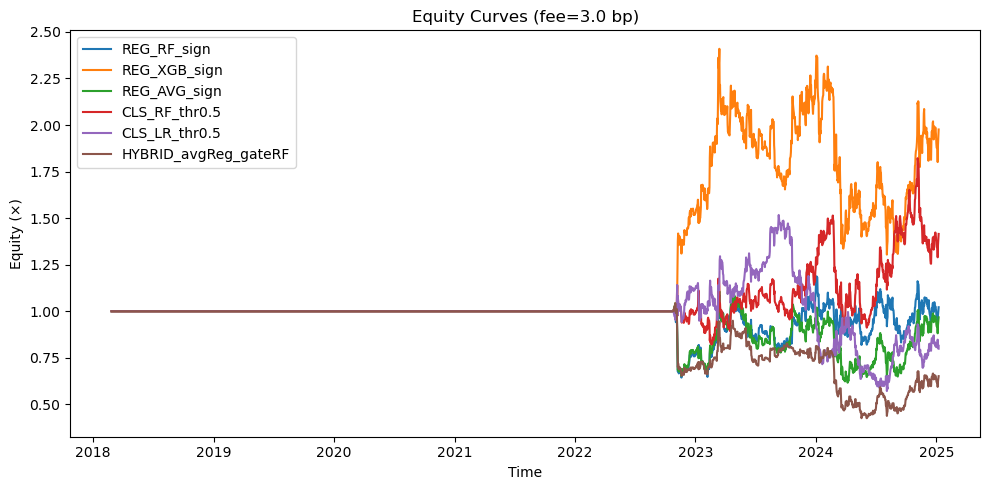

In [19]:
# ===== STEP 6 (adjusted): Multi-strategy trading backtest using all available predictions =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def backtest_pnl(returns: pd.Series, signal: pd.Series, fee_bp: float = 3.0):
    """
    returns: actual next-period *raw* returns (Series aligned by index)
    signal : position in {-1, 0, +1} (aligned to returns)
    fee_bp : round-trip fee (basis points)
    """
    pos = signal.fillna(0.0)
    gross = pos * returns
    churn = pos.diff().abs().fillna(0.0)     # position flips/changes
    fee = churn * (fee_bp / 10000.0)
    net = gross - fee
    equity = (1.0 + net).cumprod()
    return equity, net

def _to_series(x, idx, name):
    if x is None:
        return None
    s = pd.Series(x, index=getattr(x, "index", idx))
    return s.reindex(idx).rename(name)

# --- Guards & alignment
assert "dataset" in globals(), "dataset is missing."
assert "final_features" in globals(), "final_features is missing."
assert "target_col" in globals() or "target_reg" in globals(), "target variable name missing."

target_reg = globals().get("target_reg", None) or globals().get("target_col", None)
assert target_reg in dataset.columns, f"{target_reg} not found in dataset."

index = dataset.index

# --- Decide if target is log-return or simple-return
IS_LOG_TARGET = "log" in target_reg.lower()  # simple heuristic by name

true_target = dataset[target_reg].reindex(index).fillna(0.0)
true_ret = np.expm1(true_target) if IS_LOG_TARGET else true_target
true_ret = pd.Series(true_ret, index=index, name="true_ret")

# --- Collect available prediction sources
reg_rf   = _to_series(globals().get("reg_preds", None), index, "reg_rf")    # RandomForest regression preds
reg_xgb  = _to_series(globals().get("xgb_preds", None), index, "reg_xgb")   # XGBoost regression preds
proba_rf = _to_series(globals().get("cls_proba", None), index, "proba_rf")  # RF classifier probabilities (class=up)
proba_lr = _to_series(globals().get("cls_proba_lr", None), index, "proba_lr")  # LogisticRegression probabilities

# Convert regression predictions to raw return space (if target was log-return)
def _pred_to_raw_ret(pred_series: pd.Series) -> pd.Series | None:
    if pred_series is None:
        return None
    if IS_LOG_TARGET:
        return pd.Series(np.expm1(pred_series.values), index=pred_series.index, name=pred_series.name + "_raw")
    else:
        return pred_series.rename(pred_series.name + "_raw")

pred_rf_raw  = _pred_to_raw_ret(reg_rf)
pred_xgb_raw = _pred_to_raw_ret(reg_xgb)

# --- Build strategy signals dict {-1,0,+1}
strategies = {}

# 1) Sign(pred) from RF regression
if pred_rf_raw is not None:
    strategies["REG_RF_sign"] = np.sign(pred_rf_raw).rename("REG_RF_sign")

# 2) Sign(pred) from XGB regression
if pred_xgb_raw is not None:
    strategies["REG_XGB_sign"] = np.sign(pred_xgb_raw).rename("REG_XGB_sign")

# 3) Average of regressions → sign (if both available)
if (pred_rf_raw is not None) and (pred_xgb_raw is not None):
    avg_pred = ((pred_rf_raw.fillna(0) + pred_xgb_raw.fillna(0)) / 2.0)
    strategies["REG_AVG_sign"] = np.sign(avg_pred).rename("REG_AVG_sign")

# 4) Classifier RF probability → long/short by threshold
if proba_rf is not None:
    thr = 0.5
    sig = pd.Series(0, index=index, dtype=float)
    sig[proba_rf >= thr] = +1.0
    sig[proba_rf <  thr] = -1.0
    strategies["CLS_RF_thr0.5"] = sig.rename("CLS_RF_thr0.5")

# 5) Classifier LR probability → long/short by threshold
if proba_lr is not None:
    thr = 0.5
    sig = pd.Series(0, index=index, dtype=float)
    sig[proba_lr >= thr] = +1.0
    sig[proba_lr <  thr] = -1.0
    strategies["CLS_LR_thr0.5"] = sig.rename("CLS_LR_thr0.5")

# 6) Hybrid: average of regressions gated by classifier RF confidence (if available)
if ("REG_AVG_sign" in strategies) and (proba_rf is not None):
    # Gate to flat when classifier probability is too close to 0.5
    conf_band = 0.05  # inside (0.45,0.55) → go flat
    avg_sign = strategies["REG_AVG_sign"].copy()
    gate = (proba_rf - 0.5).abs() >= conf_band
    hybrid = avg_sign.where(gate, 0.0)
    strategies["HYBRID_avgReg_gateRF"] = hybrid.rename("HYBRID_avgReg_gateRF")

# --- If nothing is available, stop gracefully
if not strategies:
    raise RuntimeError("No predictions found (reg_preds/xgb_preds/cls_proba/cls_proba_lr). Run model steps first.")

# --- Backtest each strategy
fee_bp = 3.0
equity_curves = {}
summ_rows = []

for name, sig in strategies.items():
    eq, net = backtest_pnl(true_ret, sig, fee_bp=fee_bp)
    equity_curves[name] = eq

    # Summary stats
    tot_return = float(eq.iloc[-1] - 1.0)
    mean_net   = float(net.mean())
    vol_net    = float(net.std(ddof=1))
    sharpe     = (mean_net / vol_net * np.sqrt(252.0)) if vol_net > 0 else np.nan
    turnover   = float(sig.diff().abs().sum())
    hitrate    = float((np.sign(net) > 0).mean())

    summ_rows.append({
        "Strategy": name,
        "Bars": len(net),
        "Total Return (×-1)": tot_return,
        "Avg Net / bar": mean_net,
        "Std Net / bar": vol_net,
        "Sharpe≈": sharpe,
        "Turnover": turnover,
        "HitRate": hitrate,
    })

summary = pd.DataFrame(summ_rows).sort_values("Total Return (×-1)", ascending=False)
print(f"Fee: {fee_bp} bp round-trip | Target: {target_reg} | Interpreted as {'LOG' if IS_LOG_TARGET else 'SIMPLE'} returns")
print("\nStrategy summary:")
print(summary.to_string(index=False))

# --- Plot all equity curves
plt.figure(figsize=(10, 5))
for name, eq in equity_curves.items():
    plt.plot(eq.index, eq.values, label=name)
plt.title(f"Equity Curves (fee={fee_bp} bp)")
plt.xlabel("Time")
plt.ylabel("Equity (×)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


Top 15 permutation importances (test set):


,PI_mean,PI_std
momentum_pvo_hist,0.015701,0.007735
sma50,0.012846,0.004516
slope,0.012797,0.014941
open,0.009487,0.004924
high,0.008814,0.005789
momentum_pvo_signal,0.006784,0.002368
ema50,0.005944,0.004328
sent_neu,0.002706,0.005424
volume,0.001098,0.012788
momentum_pvo,0.000495,0.001545


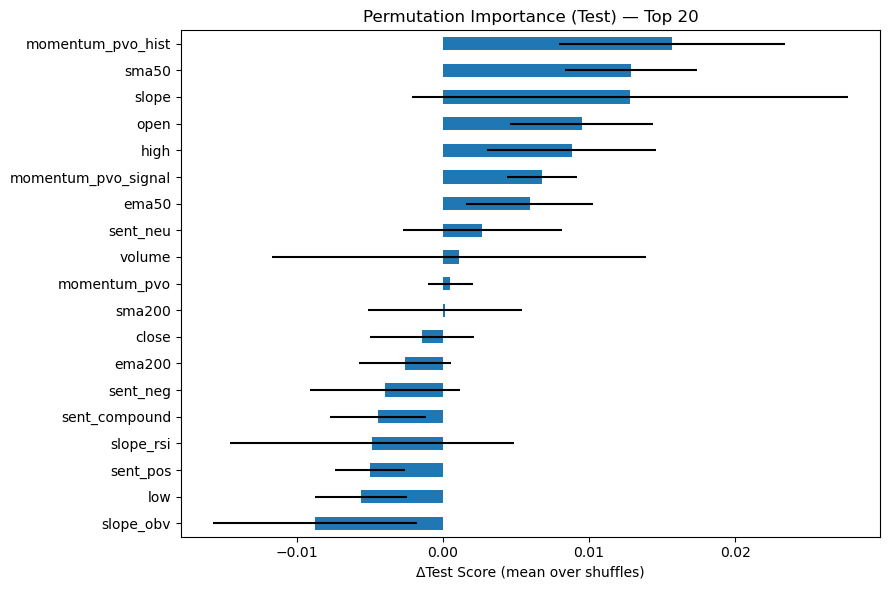


Bucketed permutation importance (sum of feature importances):


,PI_mean_sum
bucket,
technical,0.038561
market,0.012356
sentiment,-0.010668


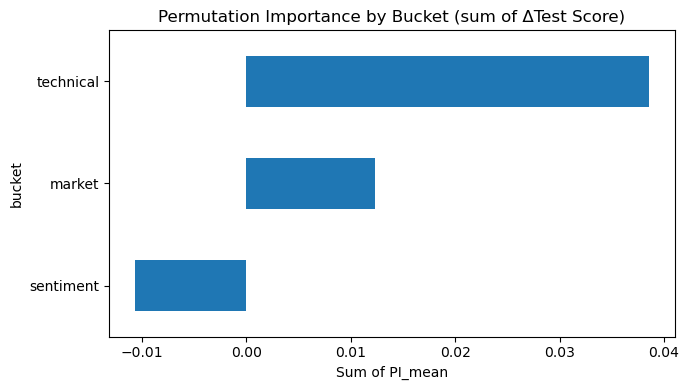


Top features within each bucket:


,bucket,top_features
0,technical,"momentum_pvo_hist (0.0157), sma50 (0.01285), s..."
1,market,"open (0.009487), high (0.008814), volume (0.00..."
2,sentiment,"sent_neu (0.002706), sent_neg (-0.003944), sen..."


In [20]:
# ===== STEP 7 (adjusted): Permutation importance including new features (network + sentiment) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor

# --- Guards
required_vars = ["X_train_scaled", "y_train", "X_test_scaled", "y_test", "final_features", "feature_catalog"]
for v in required_vars:
    if v not in globals():
        raise RuntimeError(f"Missing variable `{v}`. Make sure the daily pipeline (split & scaling) ran successfully.")

if X_test_scaled.empty:
    raise RuntimeError("X_test_scaled is empty; cannot run permutation importance.")

# Align columns defensively (just in case something changed)
X_train_scaled = X_train_scaled[final_features]
X_test_scaled  = X_test_scaled[final_features]

# --- Fit a final model on the (train) split (no leakage: we never touch test until permutation)
rf_final = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42, n_jobs=-1
)
rf_final.fit(X_train_scaled, y_train)

# --- Permutation importance ON TEST ONLY
imp = permutation_importance(
    rf_final, X_test_scaled, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)

perm_importance = pd.Series(imp.importances_mean, index=X_test_scaled.columns).sort_values(ascending=False)
perm_std        = pd.Series(imp.importances_std,  index=X_test_scaled.columns).reindex(perm_importance.index)

print("Top 15 permutation importances (test set):")
display(perm_importance.head(15).to_frame("PI_mean").assign(PI_std=perm_std.head(15)))

# --- Plot top-k individual features
top_k = 20
plt.figure(figsize=(9,6))
perm_importance.head(top_k).iloc[::-1].plot(kind="barh", xerr=perm_std.head(top_k).iloc[::-1].values)
plt.title("Permutation Importance (Test) — Top 20")
plt.xlabel("ΔTest Score (mean over shuffles)")
plt.tight_layout()
plt.show()

# ============ NEW: bucketed/grouped importance ============

# Map each feature to a bucket using your feature_catalog
bucket_of = {}
for bucket_name, cols in feature_catalog.items():
    for c in cols:
        bucket_of[c] = bucket_name

# Any feature not explicitly declared falls into 'other'
feature_buckets = [bucket_of.get(c, "other") for c in perm_importance.index]

imp_df = pd.DataFrame({
    "feature": perm_importance.index,
    "PI_mean": perm_importance.values,
    "PI_std":  perm_std.values,
    "bucket":  feature_buckets
})

# Aggregate by bucket (sum of importances; you can also try mean)
bucket_importance = (
    imp_df.groupby("bucket", dropna=False)["PI_mean"]
          .sum()
          .sort_values(ascending=False)
)

print("\nBucketed permutation importance (sum of feature importances):")
display(bucket_importance.to_frame("PI_mean_sum"))

# Plot bucketed view
plt.figure(figsize=(7,4))
bucket_importance.iloc[::-1].plot(kind="barh")
plt.title("Permutation Importance by Bucket (sum of ΔTest Score)")
plt.xlabel("Sum of PI_mean")
plt.tight_layout()
plt.show()

# ============ OPTIONAL: show top features per bucket ============
top_by_bucket_rows = []
for b in bucket_importance.index:
    top_feats = (
        imp_df[imp_df["bucket"] == b]
        .sort_values("PI_mean", ascending=False)
        .head(5)[["feature","PI_mean"]]
        .values
    )
    # store as a compact string
    top_by_bucket_rows.append({
        "bucket": b,
        "top_features": ", ".join([f"{f} ({v:.4g})" for f, v in top_feats])
    })

top_by_bucket = pd.DataFrame(top_by_bucket_rows)
print("\nTop features within each bucket:")
display(top_by_bucket)


In [21]:
# ===== STEP 8 (adjusted): Small hyperparameter search for RF (chronological, leakage-safe) =====
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# --- Guards
for v in ["dataset", "final_features", "target_col"]:
    if v not in globals():
        raise RuntimeError(f"Missing `{v}`. Run the daily pipeline first.")

features   = final_features
target_reg = target_col

# Outer split (80/20) — consistent with your pipeline
N = len(dataset)
split_idx = max(1, min(int(N * 0.8), N - 1))
train = dataset.iloc[:split_idx].copy()
test  = dataset.iloc[split_idx:].copy()

# Inner (chronological) validation split inside the train
inner_idx = max(1, min(int(len(train) * 0.8), len(train) - 1))
sub_tr = train.iloc[:inner_idx].copy()
sub_va = train.iloc[inner_idx:].copy()

X_tr, y_tr = sub_tr[features], sub_tr[target_reg]
X_va, y_va = sub_va[features], sub_va[target_reg]

# Scale inside inner split (no leakage)
sc_inner = StandardScaler().fit(X_tr)
X_trs = sc_inner.transform(X_tr)
X_vas = sc_inner.transform(X_va)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 12],
    "min_samples_leaf": [1, 2, 4],
}

best_score  = np.inf
best_params = None

for params in ParameterGrid(param_grid):
    rf = RandomForestRegressor(random_state=42, n_jobs=-1, **params)
    rf.fit(X_trs, y_tr)
    y_hat = rf.predict(X_vas)
    rmse = float(np.sqrt(mean_squared_error(y_va.values, y_hat)))
    if rmse < best_score:
        best_score, best_params = rmse, params
        print(f"New best on inner val — RMSE={best_score:.6f} | {best_params}")

print("\nBest RF params (inner val):", best_params)

# ---- Refit on FULL outer-train using best params, then evaluate on test ----
X_train_full, y_train_full = train[features], train[target_reg]
X_test_full,  y_test_full  = test[features],  test[target_reg]

sc_outer = StandardScaler().fit(X_train_full)
X_train_full_s = sc_outer.transform(X_train_full)
X_test_full_s  = sc_outer.transform(X_test_full)

rf_best = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
rf_best.fit(X_train_full_s, y_train_full)
y_test_pred = rf_best.predict(X_test_full_s)

rmse_test = float(np.sqrt(mean_squared_error(y_test_full.values, y_test_pred)))
mae_test  = float(np.mean(np.abs(y_test_full.values - y_test_pred)))
print(f"Outer Test — RMSE={rmse_test:.6f} | MAE={mae_test:.6f}")

# (Optional) keep predictions aligned for later analysis/backtests
rf_test_preds = pd.Series(y_test_pred, index=y_test_full.index, name="rf_test_pred")


New best on inner val — RMSE=0.027122 | {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
New best on inner val — RMSE=0.027008 | {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
New best on inner val — RMSE=0.026729 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 200}
New best on inner val — RMSE=0.026674 | {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}
New best on inner val — RMSE=0.026370 | {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 200}
New best on inner val — RMSE=0.026193 | {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}

Best RF params (inner val): {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 200}
Outer Test — RMSE=0.027140 | MAE=0.019362


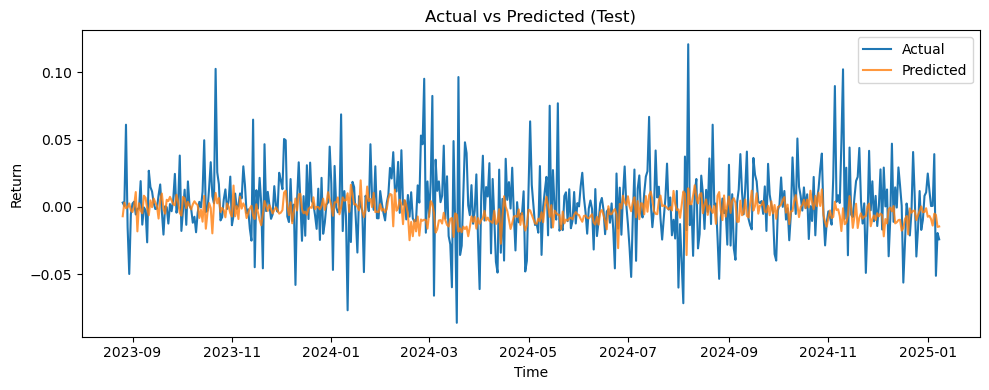

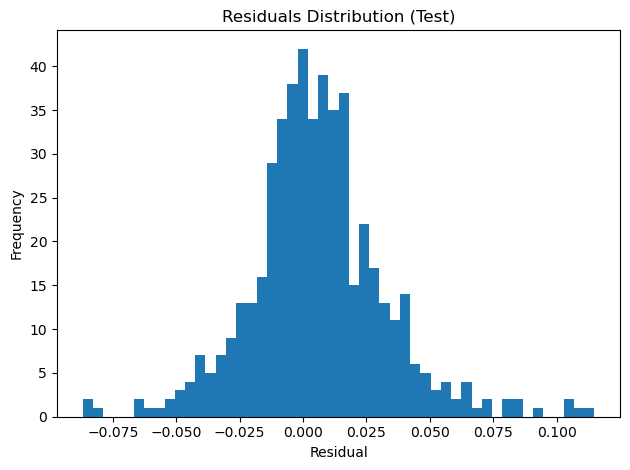

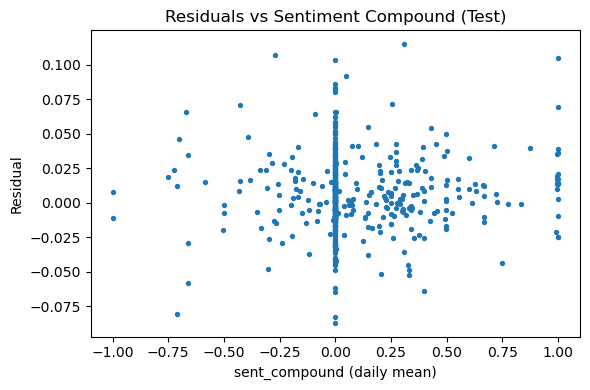

In [22]:
# ===== STEP 9 (adjusted): Sanity plots (no seaborn, single-plot rule) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Guards & setup
assert "dataset" in globals() and "y_test" in globals(), "Run the pipeline/splits first."
assert "final_features" in globals(), "final_features missing."

# Use your regression target name
target_reg = globals().get("target_reg", None) or globals().get("target_col", None)
assert target_reg in dataset.columns, f"{target_reg} not found in dataset."

# Detect log vs simple returns from the name
IS_LOG_TARGET = "log" in target_reg.lower()

# Pick a prediction source (try RF, then XGB)
pred_series = None
if "reg_preds" in globals() and isinstance(reg_preds, pd.Series) and not reg_preds.dropna().empty:
    pred_series = reg_preds
elif "xgb_preds" in globals() and isinstance(xgb_preds, pd.Series) and not xgb_preds.dropna().empty:
    pred_series = xgb_preds
else:
    raise RuntimeError("No regression predictions found (reg_preds/xgb_preds).")

# Align to test index
pred_aligned = pred_series.reindex(y_test.index).astype(float)

# If target is log-return but you want to visualize in simple-return space, toggle below:
VISUALIZE_AS_SIMPLE = False  # set True to show simple returns even when target is log
y_true_vis = pd.Series(y_test.values, index=y_test.index, name="y_true")
y_pred_vis = pd.Series(pred_aligned.values, index=y_test.index, name="y_pred")

if IS_LOG_TARGET and VISUALIZE_AS_SIMPLE:
    y_true_vis = np.expm1(y_true_vis)
    y_pred_vis = np.expm1(y_pred_vis)
    y_label = "Return"
else:
    y_label = "Log-Return" if IS_LOG_TARGET else "Return"

# ===== 1) Actual vs Predicted on the test period =====
plt.figure(figsize=(10, 4))
plt.plot(y_true_vis.index, y_true_vis.values, label="Actual")
plt.plot(y_pred_vis.index, y_pred_vis.values, label="Predicted", alpha=0.8)
plt.legend()
plt.title("Actual vs Predicted (Test)")
plt.xlabel("Time")
plt.ylabel(y_label)
plt.tight_layout()
plt.show()

# ===== 2) Residuals histogram (test) =====
resid = (y_true_vis - y_pred_vis).values
plt.figure()
plt.hist(resid, bins=50)
plt.title("Residuals Distribution (Test)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ===== 3) NEW: Residuals vs Network feature (hash_rate) =====
if "hash_rate" in dataset.columns:
    hr_test = dataset.loc[y_test.index, "hash_rate"].astype(float)
    # If hash_rate has huge scale, consider log
    hr_plot = np.log1p(hr_test) if (hr_test.max() / max(hr_test.min(), 1e-9) > 1e4) else hr_test

    plt.figure(figsize=(6, 4))
    plt.scatter(hr_plot.values, (y_true_vis - y_pred_vis).values, s=8)
    plt.title("Residuals vs Hash Rate (Test)")
    plt.xlabel("hash_rate (log1p if large scale)")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()

# ===== 4) NEW: Residuals vs Sentiment feature (sent_compound) =====
if "sent_compound" in dataset.columns:
    sc_test = dataset.loc[y_test.index, "sent_compound"].astype(float)

    plt.figure(figsize=(6, 4))
    plt.scatter(sc_test.values, (y_true_vis - y_pred_vis).values, s=8)
    plt.title("Residuals vs Sentiment Compound (Test)")
    plt.xlabel("sent_compound (daily mean)")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


[LSTM] Cadence detected: DAILY | Window=30 | Epochs=25
Seq shapes (train/test): (1976, 30, 19) (472, 30, 19)
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - loss: 0.7289 - val_loss: 0.1122
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 0.0919 - val_loss: 0.0158
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - loss: 0.0717 - val_loss: 0.0777
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0487 - val_loss: 0.0230
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0323 - val_loss: 0.0168
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - loss: 0.0256 - val_loss: 0.0225
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - loss: 0.0242 - val_loss: 0.0201
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.
LSTM (price) Test RMSE: 19964.078125
LSTM (price) Directional Acc: 0.5063559322033898


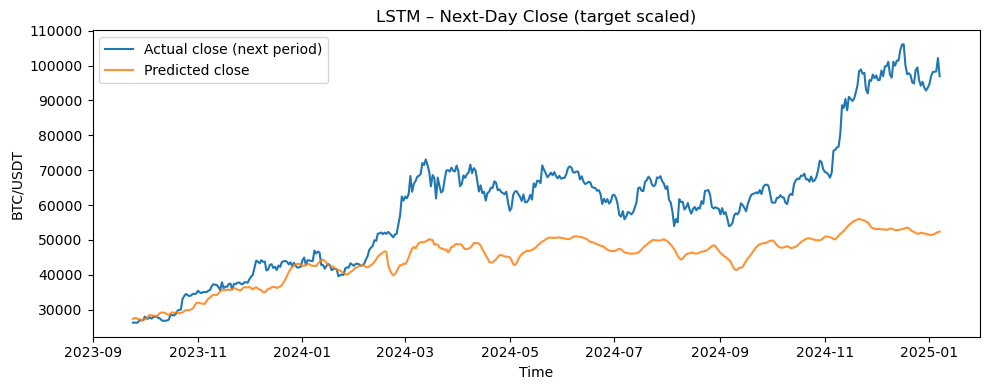

In [23]:
# ===== STEP 10: LSTM – Next-period CLOSE with TARGET SCALING (daily/hourly aware) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler

# ---------- Guards ----------
assert "dataset" in globals() and "final_features" in globals(), "Run the pipeline first."
assert isinstance(dataset.index, pd.DatetimeIndex), "dataset index must be a DateTimeIndex."

# ---------- Cadence detection (daily vs hourly) ----------
# We'll infer cadence from the median step of the index (robust to gaps)
_median_step = dataset.index.to_series().diff().median()
is_daily = (_median_step is not pd.NaT) and (_median_step >= pd.Timedelta(hours=23))

SEQ_WINDOW = 30 if is_daily else 24     # ~1 month for daily, 1 day for hourly
VAL_SPLIT  = 0.1                        # inside-train validation fraction
EPOCHS     = 25
BATCH_SIZE = 256

print(f"[LSTM] Cadence detected: {'DAILY' if is_daily else 'HOURLY'} | Window={SEQ_WINDOW} | Epochs={EPOCHS}")

# ---------- Target: next-period close ----------
if "y_close_t1" not in dataset.columns:
    dataset["y_close_t1"] = dataset["close"].shift(-1)

# Keep only rows where we have target (no leakage)
df_lstm = dataset.dropna(subset=["y_close_t1"]).copy()

# ---------- Features: use your final_features (includes market/technical/network/sentiment as available) ----------
# Ensure all are present; drop any that went missing after prior pruning (defensive)
use_features = [f for f in final_features if f in df_lstm.columns]

if not use_features:
    raise RuntimeError("No usable features found for LSTM. Check `final_features` and dataset columns.")

# Remove any remaining NaNs in X for stability (forward-fill is OK here; we still predict t+1 using t..t-k)
df_lstm[use_features] = df_lstm[use_features].ffill()

# ---------- Chronological train/test (80/20) ----------
split_idx = int(len(df_lstm) * 0.8)
train = df_lstm.iloc[:split_idx].copy()
test  = df_lstm.iloc[split_idx:].copy()

# ---------- Scale features on TRAIN only (no leakage) ----------
X_scaler = StandardScaler().fit(train[use_features])
Xtr = pd.DataFrame(X_scaler.transform(train[use_features]), index=train.index, columns=use_features)
Xte = pd.DataFrame(X_scaler.transform(test[use_features]),  index=test.index,  columns=use_features)

# ---------- Scale target (price) on TRAIN only ----------
y_scaler = StandardScaler().fit(train[["y_close_t1"]])
ytr = pd.Series(y_scaler.transform(train[["y_close_t1"]]).ravel(), index=train.index, name="y_scaled")
yte = pd.Series(y_scaler.transform(test[["y_close_t1"]]).ravel(),  index=test.index,  name="y_scaled")

# ---------- Sequence builder ----------
def make_sequences(X_df, y_series, window: int):
    Xv = X_df.values.astype(np.float32)
    yv = y_series.values.astype(np.float32)
    X_seq, y_seq, idx = [], [], []
    for i in range(window, len(Xv)):
        X_seq.append(Xv[i-window:i])
        y_seq.append(yv[i])
        idx.append(X_df.index[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx)

WINDOW = SEQ_WINDOW
Xtr_seq, ytr_seq, _     = make_sequences(Xtr, ytr, window=WINDOW)
Xte_seq, yte_seq, idx_t = make_sequences(Xte, yte, window=WINDOW)

print("Seq shapes (train/test):", Xtr_seq.shape, Xte_seq.shape)
if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
    raise RuntimeError("Not enough rows to build sequences. Reduce WINDOW or provide more data.")

# ---------- Model ----------
model = models.Sequential([
    layers.Input(shape=(Xtr_seq.shape[1], Xtr_seq.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

hist = model.fit(
    Xtr_seq, ytr_seq,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[early_stop]
)

# ---------- Predict (scaled) → inverse-transform to price ----------
yhat_scaled = model.predict(Xte_seq, verbose=0).ravel()
yhat_price  = y_scaler.inverse_transform(yhat_scaled.reshape(-1,1)).ravel()
ytrue_price = y_scaler.inverse_transform(yte_seq.reshape(-1,1)).ravel()

# ---------- Metrics ----------
def rmse_np(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def directional_accuracy_price(y_true, y_pred):
    # Direction from previous point (simple sign of diff)
    true_dir = np.sign(np.diff(y_true, prepend=y_true[0]))
    pred_dir = np.sign(np.diff(y_pred, prepend=y_pred[0]))
    return float((true_dir == pred_dir).mean())

print("LSTM (price) Test RMSE:", rmse_np(ytrue_price, yhat_price))
print("LSTM (price) Directional Acc:", directional_accuracy_price(ytrue_price, yhat_price))

# ---------- Plot ----------
plt.figure(figsize=(10,4))
plt.plot(idx_t, ytrue_price, label="Actual close (next period)")
plt.plot(idx_t, yhat_price,  label="Predicted close", alpha=0.85)
title_freq = "Next-Day" if is_daily else "Next-Hour"
plt.title(f"LSTM – {title_freq} Close (target scaled)")
plt.xlabel("Time"); plt.ylabel("BTC/USDT")
plt.legend(); plt.tight_layout()
plt.show()

# ---------- (Optional) save objects you might reuse ----------
lstm_preds_price = pd.Series(yhat_price, index=idx_t, name="lstm_pred_close_t1")


[LSTM-LOGRET] Cadence: DAILY | Window=30 | Epochs=25
Seq shapes (train/test): (1976, 30, 19) (472, 30, 19)
Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - loss: 0.0430 - val_loss: 0.0016
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step - loss: 0.0115 - val_loss: 0.0018
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0065 - val_loss: 0.0014
Epoch 4/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0051 - val_loss: 7.6643e-04
Epoch 5/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 6/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - loss: 0.0035 - val_loss: 0.0015
Epoch 7/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.0036 - val_loss: 9.9623e-04
Epoch 8/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0030 - val_loss: 7.6157e-04
Epoch 9/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0029 - val_loss: 8.8164e-04
Epoch 10/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - loss: 0.0026 - val_loss: 7.5517e-04
Epoch 11/25
7/7 ━━━━━━━━━━━━━━━━━

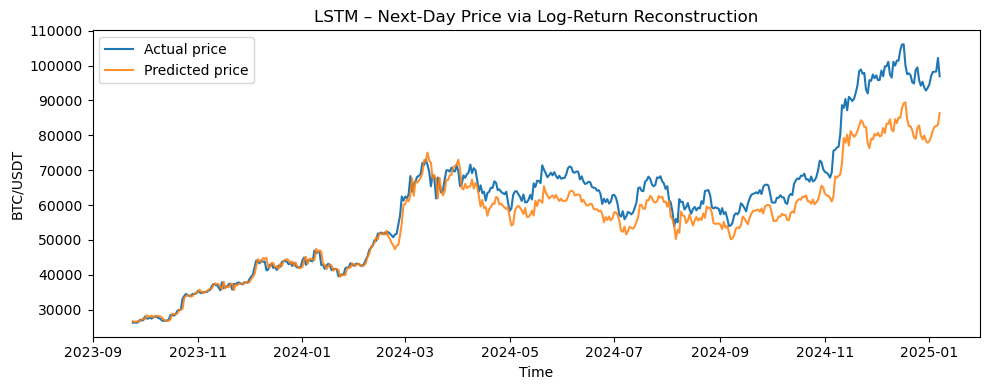

In [24]:
# ===== STEP 10b: LSTM — Next-period PRICE via LOG-RETURN (reconstruction), using all features =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.preprocessing import StandardScaler

# ---------- Guards ----------
assert "dataset" in globals() and "final_features" in globals(), "Run the pipeline first."
assert isinstance(dataset.index, pd.DatetimeIndex), "dataset index must be a DateTimeIndex."

# ---------- Cadence detection (daily vs hourly) ----------
_median_step = dataset.index.to_series().diff().median()
is_daily = (_median_step is not pd.NaT) and (_median_step >= pd.Timedelta(hours=23))
WINDOW = 30 if is_daily else 24   # ~1 month if daily, 1 day if hourly
VAL_SPLIT = 0.1
EPOCHS    = 25
BATCH     = 256

print(f"[LSTM-LOGRET] Cadence: {'DAILY' if is_daily else 'HOURLY'} | Window={WINDOW} | Epochs={EPOCHS}")

# ---------- Build log-return target ----------
df_lr = dataset.copy()
df_lr["log_price"]   = np.log(df_lr["close"])
df_lr["y_logret_t1"] = df_lr["log_price"].shift(-1) - df_lr["log_price"]  # log(P_{t+1}) - log(P_t)
df_lr["P_t"]         = df_lr["close"]                                      # to reconstruct P_{t+1} = P_t * exp(y_logret_t1)

# Keep rows where target & P_t are available
df_lr = df_lr.dropna(subset=["y_logret_t1", "P_t"]).copy()

# ---------- Feature set (includes market/technical/network/sentiment) ----------
use_features = [f for f in final_features if f in df_lr.columns]
if not use_features:
    raise RuntimeError("No usable features for LSTM. Check `final_features` vs dataset columns.")

# Forward-fill features only (no bfill to avoid peeking)
df_lr[use_features] = df_lr[use_features].ffill()

# ---------- Chronological split (80/20) ----------
split_idx = int(len(df_lr) * 0.8)
train = df_lr.iloc[:split_idx].copy()
test  = df_lr.iloc[split_idx:].copy()

# ---------- Scale features on TRAIN only (no leakage) ----------
X_scaler = StandardScaler().fit(train[use_features])
Xtr = pd.DataFrame(X_scaler.transform(train[use_features]), index=train.index, columns=use_features)
Xte = pd.DataFrame(X_scaler.transform(test[use_features]),  index=test.index,  columns=use_features)

# Targets (log-returns are already ~zero-mean small scale → no target scaler needed)
ytr = train["y_logret_t1"].astype(np.float32)
yte = test["y_logret_t1"].astype(np.float32)

# P_t for reconstruction aligned to test indices
Pt_test = test["P_t"].astype(np.float32)

# ---------- Sequence builder ----------
def make_sequences(X_df, y_series, window: int):
    Xv = X_df.values.astype(np.float32)
    yv = y_series.values.astype(np.float32)
    X_seq, y_seq, idx = [], [], []
    for i in range(window, len(Xv)):
        X_seq.append(Xv[i-window:i])
        y_seq.append(yv[i])
        idx.append(X_df.index[i])
    return np.array(X_seq), np.array(y_seq), pd.Index(idx)

Xtr_seq, ytr_seq, _     = make_sequences(Xtr, ytr, window=WINDOW)
Xte_seq, yte_seq, idx_t = make_sequences(Xte, yte, window=WINDOW)

if len(Xtr_seq) == 0 or len(Xte_seq) == 0:
    raise RuntimeError("Not enough rows to build sequences. Reduce WINDOW or provide more data.")

# Align P_t to test sequence timestamps
Pt_seq = Pt_test.loc[idx_t].values

print("Seq shapes (train/test):", Xtr_seq.shape, Xte_seq.shape)

# ---------- Model ----------
model = models.Sequential([
    layers.Input(shape=(Xtr_seq.shape[1], Xtr_seq.shape[2])),
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")

early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

hist = model.fit(
    Xtr_seq, ytr_seq,
    validation_split=VAL_SPLIT,
    epochs=EPOCHS,
    batch_size=BATCH,
    verbose=1,
    callbacks=[early_stop]
)

# ---------- Predict log-returns → reconstruct price ----------
yhat_logret = model.predict(Xte_seq, verbose=0).ravel().astype(np.float64)
ytrue_logret = yte_seq.astype(np.float64)

# P_{t+1} = P_t * exp(logret_{t→t+1})
yhat_price  = Pt_seq * np.exp(yhat_logret)
ytrue_price = Pt_seq * np.exp(ytrue_logret)

# ---------- Metrics ----------
def rmse_np(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def directional_accuracy_price(y_true, y_pred):
    true_dir = np.sign(np.diff(y_true, prepend=y_true[0]))
    pred_dir = np.sign(np.diff(y_pred, prepend=y_pred[0]))
    return float((true_dir == pred_dir).mean())

print("LSTM (log-return→price) Test RMSE:", rmse_np(ytrue_price, yhat_price))
print("LSTM (log-return→price) Directional Acc:", directional_accuracy_price(ytrue_price, yhat_price))

# ---------- Plot ----------
plt.figure(figsize=(10,4))
plt.plot(idx_t, ytrue_price, label="Actual price")
plt.plot(idx_t, yhat_price,  label="Predicted price", alpha=0.85)
title_freq = "Next-Day" if is_daily else "Next-Hour"
plt.title(f"LSTM – {title_freq} Price via Log-Return Reconstruction")
plt.xlabel("Time"); plt.ylabel("BTC/USDT")
plt.legend(); plt.tight_layout()
plt.show()

# (Optional) keep predictions for later backtests
lstm_logret_preds = pd.Series(yhat_logret, index=idx_t, name="lstm_pred_logret_t1")
lstm_price_preds  = pd.Series(yhat_price,  index=idx_t, name="lstm_pred_price_t1")


In [25]:
# ===== DATA QUALITY DIAGNOSTICS (cadence-aware; includes new features) =====
import pandas as pd
import numpy as np

# Pick a frame to inspect: prefer your modeling frame if present
df_to_check = None
if "df_daily" in globals():
    df_to_check = df_daily.copy()
elif "dataset" in globals():
    # dataset is post-shift; for quality checks on raw features use the unshifted df if you kept one.
    df_to_check = dataset.copy()
elif "df" in globals():
    df_to_check = df.copy()
else:
    raise RuntimeError("No dataframe found. Expected one of: df_daily, dataset, or df.")

if not isinstance(df_to_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Cadence detection ---
med_step = df_to_check.index.to_series().diff().median()
is_daily = (med_step is not pd.NaT) and (med_step >= pd.Timedelta(hours=23))
freq_label = "DAILY" if is_daily else "HOURLY"

print(f"[INFO] Cadence detected: {freq_label}")
print("Index range:", df_to_check.index.min(), "→", df_to_check.index.max())
print("Rows:", len(df_to_check), "| Cols:", len(df_to_check.columns))

# --- Duplicates (exact timestamp duplicates) ---
dup_count = df_to_check.index.duplicated(keep="first").sum()
print("Duplicate timestamps:", int(dup_count))

# --- Gaps against expected cadence ---
freq = "D" if is_daily else "H"
expected = pd.date_range(df_to_check.index.min(), df_to_check.index.max(), freq=freq)
missing = expected.difference(df_to_check.index)
print(f"Missing {freq_label.lower()} bars:", len(missing))

# --- OHLCV existence check ---
ohlcv_cols = ["open","high","low","close","volume"]
missing_ohlcv = [c for c in ohlcv_cols if c not in df_to_check.columns]
if missing_ohlcv:
    print("[WARN] Missing OHLCV columns:", missing_ohlcv)
else:
    # sanity: first/max/min/last relations on any one day (for hourly), or globally (for daily)
    if not is_daily:
        day = df_to_check.index.normalize().unique()[0]
        day_slice = df_to_check[df_to_check.index.normalize() == day][ohlcv_cols]
        if not day_slice.empty:
            ok_open  = np.isfinite(day_slice["open"].iloc[0])
            ok_close = np.isfinite(day_slice["close"].iloc[-1])
            print(f"OHLCV sanity (first open finite? {ok_open}) (last close finite? {ok_close})")
    else:
        ok_any = df_to_check[ohlcv_cols].dropna().shape[0] > 0
        print(f"OHLCV sanity (has non-NaN rows?): {ok_any}")

# --- Feature catalog (use yours if available; otherwise define a minimal one) ---
if "feature_catalog" not in globals():
    feature_catalog = {
        "market": ohlcv_cols,
        "technical": [
            "sma200","sma50","ema200","ema50","RSI","rsi","slope_rsi","MACD","macd",
            "OBV","obv","Bollinger_Upper","Bollinger_Lower",
            "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
            "slope","slope_obv",
        ],
        "network": ["hash_rate","mining_difficulty"],
        "sentiment": ["sent_pos","sent_neu","sent_neg","sent_compound"],
    }

# --- Coverage by feature & by bucket (non-NaN ratio) ---
all_feats = sorted(set(sum(feature_catalog.values(), [])))
present = [c for c in all_feats if c in df_to_check.columns]
missing_feats = [c for c in all_feats if c not in df_to_check.columns]
if missing_feats:
    print("\n[INFO] Declared but missing features:", missing_feats)

cov = df_to_check[present].notna().mean().sort_values(ascending=False)
cov_df = cov.to_frame("non_na_ratio")
cov_df["bucket"] = [next((b for b, cols in feature_catalog.items() if f in cols), "other") for f in cov_df.index]

print("\nTop 15 features by coverage:")
print(cov_df.head(15))

bucket_cov = cov_df.groupby("bucket")["non_na_ratio"].mean().sort_values(ascending=False)
print("\nAverage coverage by bucket:")
print(bucket_cov)

# --- Explicit checks for new features (network + sentiment) ---
for col in ["hash_rate","mining_difficulty","sent_pos","sent_neu","sent_neg","sent_compound"]:
    if col in df_to_check.columns:
        non_na = float(df_to_check[col].notna().mean())
        start  = df_to_check.index[df_to_check[col].notna()].min()
        end    = df_to_check.index[df_to_check[col].notna()].max()
        print(f"{col:>16} | coverage={non_na:6.2%} | range: {start} → {end}")
    else:
        print(f"{col:>16} | (missing)")

# --- Top NaN columns (all columns, not only declared) ---
nan_counts = df_to_check.isna().sum().sort_values(ascending=False)
print("\nTop NaN columns (absolute counts):")
print(nan_counts.head(10))

# --- Hourly→daily join quality hint (only if daily and you expect forward-filled day-level joins) ---
if is_daily:
    # days with any sentiment info
    if all(c in df_to_check.columns for c in ["sent_pos","sent_neu","sent_neg","sent_compound"]):
        days_with_sent = df_to_check[["sent_pos","sent_neu","sent_neg","sent_compound"]].notna().any(axis=1).sum()
        print(f"\n[DAILY] Days with any sentiment data: {days_with_sent} / {len(df_to_check)}")
    if "hash_rate" in df_to_check.columns:
        days_with_hr = df_to_check["hash_rate"].notna().sum()
        print(f"[DAILY] Days with hash_rate: {days_with_hr} / {len(df_to_check)}")
else:
    # If this is hourly, check within-day constancy for day-level features (they should be constant after merge/ffill)
    day_groups = df_to_check.index.normalize()
    for col in ["hash_rate","mining_difficulty","sent_compound"]:
        if col in df_to_check.columns:
            within_day_var = df_to_check.groupby(day_groups)[col].nunique(dropna=True).mean()
            print(f"[HOURLY] mean unique values per day for {col}: {within_day_var:.2f} (expect ~1.0 if daily→hourly merge OK)")


[INFO] Cadence detected: DAILY
Index range: 2017-08-17 00:00:00 → 2025-01-09 00:00:00
Rows: 2703 | Cols: 110
Duplicate timestamps: 0
Missing daily bars: 0
OHLCV sanity (has non-NaN rows?): True

[INFO] Declared but missing features: ['Bollinger_Lower', 'Bollinger_Upper', 'MACD', 'OBV', 'RSI', 'macd', 'mining_difficulty', 'obv', 'rsi']

Top 15 features by coverage:
               non_na_ratio     bucket
close               1.00000     market
ema200              1.00000  technical
ema50               1.00000  technical
high                1.00000     market
volume              1.00000     market
low                 1.00000     market
sent_compound       1.00000  sentiment
open                1.00000     market
sent_neg            1.00000  sentiment
slope               1.00000  technical
sent_pos            1.00000  sentiment
sent_neu            1.00000  sentiment
slope_obv           1.00000  technical
slope_rsi           0.99963  technical
sma50               0.99926  technical

Average 

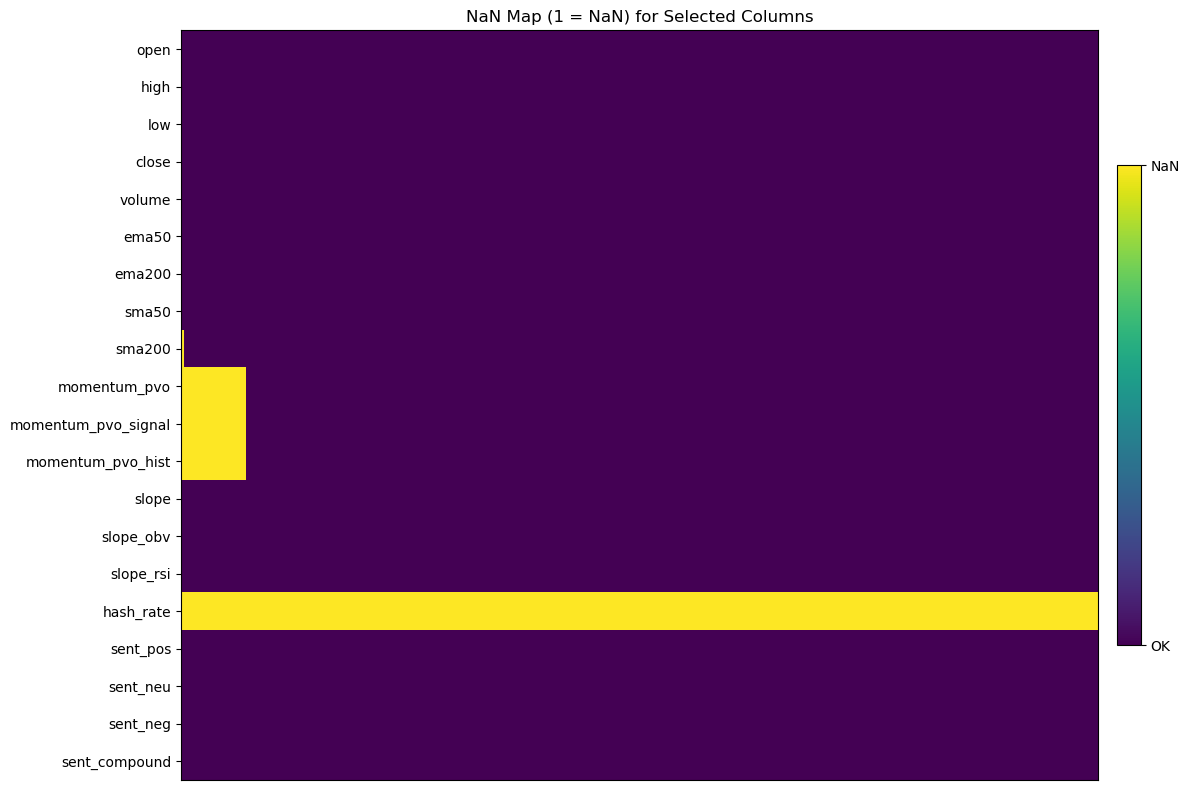

In [26]:
# ===== NaN Heatmap (includes network + sentiment; alias-aware) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Pick a dataframe to inspect
if "df_daily" in globals():
    df_to_check = df_daily
elif "dataset" in globals():
    df_to_check = dataset
elif "df" in globals():
    df_to_check = df
else:
    raise RuntimeError("No dataframe found. Expected one of: df_daily, dataset, or df.")

if not isinstance(df_to_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Preferred feature names (+ aliases) to search for
preferred_cols = [
    # OHLCV
    "open","high","low","close","volume",
    # EMA/SMA
    "ema50","ema200","sma50","sma200",
    # RSI (various casings)
    "RSI","rsi","rsi14",
    # Bollinger
    "Bollinger_Upper","Bollinger_Lower","bb_up","bb_lo",
    # Popular momentum / slopes you have
    "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
    "slope","slope_obv","slope_rsi",
    "MACD","macd","OBV","obv",
    # NEW: network
    "hash_rate","mining_difficulty",
    # NEW: sentiment
    "sent_pos","sent_neu","sent_neg","sent_compound",
]

# Resolve aliases: pick the first name that exists in the dataframe for each logical feature set
alias_groups = [
    ["RSI","rsi","rsi14"],
    ["Bollinger_Upper","bb_up"],
    ["Bollinger_Lower","bb_lo"],
    ["MACD","macd"],
    ["OBV","obv"],
]
resolved = set()
for grp in alias_groups:
    for name in grp:
        if name in df_to_check.columns:
            resolved.add(name)
            break

# Start with any preferred columns actually present
cols_present = [c for c in preferred_cols if c in df_to_check.columns]
# Remove duplicate aliases within the same logical group
cols_present = list(dict.fromkeys(cols_present))  # keep order, drop dups
# Ensure only one of each alias group is kept
for grp in alias_groups:
    keep = [c for c in grp if c in cols_present]
    if len(keep) > 1:
        # keep the first occurrence in preferred order
        for c in keep[1:]:
            cols_present.remove(c)

if not cols_present:
    raise RuntimeError("No matching columns found for NaN heatmap. Check your dataframe columns.")

# If too many columns, focus on those with most NaNs (top_k)
top_k = 30
nan_counts = df_to_check[cols_present].isna().sum().sort_values(ascending=False)
if len(cols_present) > top_k:
    cols_to_plot = nan_counts.head(top_k).index.tolist()
    print(f"[INFO] Selected top {top_k} columns by NaNs for plotting.")
else:
    cols_to_plot = cols_present

# Optionally downsample rows for speed (visual only)
max_rows = 10000
if len(df_to_check) > max_rows:
    # take evenly spaced indices
    take_idx = np.linspace(0, len(df_to_check)-1, max_rows, dtype=int)
    df_plot = df_to_check.iloc[take_idx][cols_to_plot]
else:
    df_plot = df_to_check[cols_to_plot]

# Build mask: 1 = NaN, 0 = OK
mask = df_plot.isna().astype(int).values.T  # shape: cols x rows

plt.figure(figsize=(12, 3 + 0.25*len(cols_to_plot)))
im = plt.imshow(mask, aspect="auto", interpolation="nearest")
plt.yticks(range(len(cols_to_plot)), cols_to_plot)
plt.xticks([], [])
plt.title("NaN Map (1 = NaN) for Selected Columns")
cbar = plt.colorbar(im, fraction=0.025, pad=0.02)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(["OK", "NaN"])
plt.tight_layout()
plt.show()


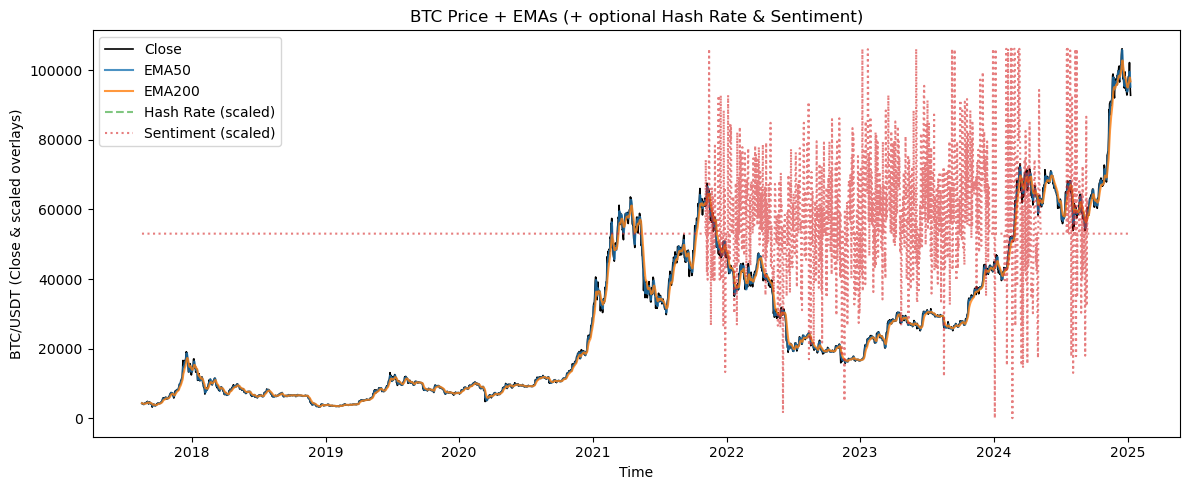

In [27]:
# ===== Sanity overlay plot: Price + EMAs + (optional) Network =====
import matplotlib.pyplot as plt

# Pick the right dataframe (daily preferred)
if "df_daily" in globals():
    df_plot = df_daily
elif "dataset" in globals():
    df_plot = dataset
elif "df" in globals():
    df_plot = df
else:
    raise RuntimeError("No dataframe found. Expected df_daily, dataset, or df.")

plt.figure(figsize=(12,5))

# --- Price
plt.plot(df_plot.index, df_plot["close"], label="Close", color="black", linewidth=1.2)

# --- EMAs (if available)
if "ema50" in df_plot.columns:  
    plt.plot(df_plot.index, df_plot["ema50"],  label="EMA50", alpha=0.8)
if "ema200" in df_plot.columns: 
    plt.plot(df_plot.index, df_plot["ema200"], label="EMA200", alpha=0.8)

# --- Optionally overlay hash rate (scaled for visualization)
if "hash_rate" in df_plot.columns:
    hr_scaled = (df_plot["hash_rate"] / df_plot["hash_rate"].max()) * df_plot["close"].max()
    plt.plot(df_plot.index, hr_scaled, label="Hash Rate (scaled)", linestyle="--", alpha=0.6)

# --- Optionally overlay sentiment compound (scaled)
if "sent_compound" in df_plot.columns:
    sent_scaled = (df_plot["sent_compound"] - df_plot["sent_compound"].min())
    sent_scaled = sent_scaled / (sent_scaled.max() + 1e-8) * df_plot["close"].max()
    plt.plot(df_plot.index, sent_scaled, label="Sentiment (scaled)", linestyle=":", alpha=0.6)

plt.title("BTC Price + EMAs (+ optional Hash Rate & Sentiment)")
plt.xlabel("Time")
plt.ylabel("BTC/USDT (Close & scaled overlays)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


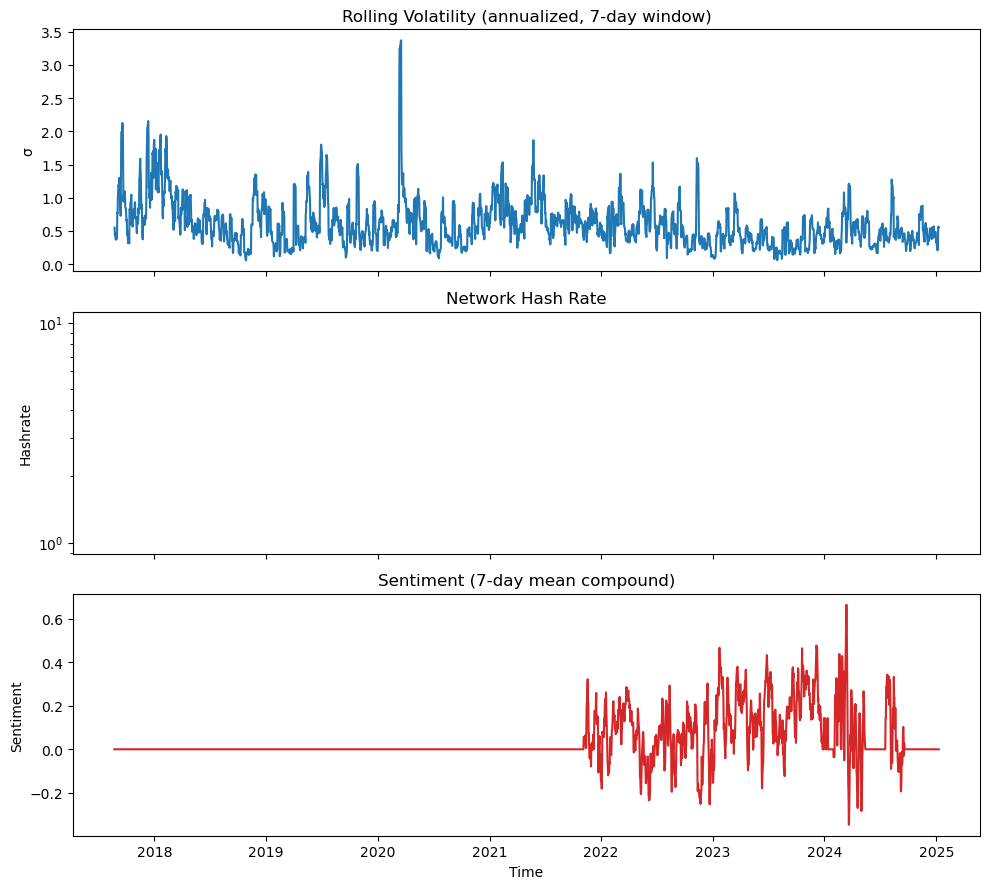

In [28]:
# ===== Rolling Volatility + Network + Sentiment =====
import matplotlib.pyplot as plt
import numpy as np

# Pick the correct df (daily preferred, fallback hourly)
if "df_daily" in globals():
    df_vol = df_daily
elif "df" in globals():
    df_vol = df
else:
    raise RuntimeError("No dataframe found. Expected df_daily or df.")

# --- Compute hourly/daily returns depending on data freq ---
if df_vol.index.freq is not None and "D" in str(df_vol.index.freq):
    # daily data
    ret = df_vol["close"].pct_change()
    roll_vol = ret.rolling(7).std() * np.sqrt(365)   # 7-day rolling, annualized
else:
    # hourly data
    ret = df_vol["close"].pct_change()
    roll_vol = ret.rolling(24*7).std() * np.sqrt(24*365)  # 7-day window, annualized

# --- Sentiment (smoothed 7-day mean if available) ---
sent = None
if "sent_compound" in df_vol.columns:
    sent = df_vol["sent_compound"].rolling(7).mean()

# --- Hash rate (log scale if available) ---
hashrate = None
if "hash_rate" in df_vol.columns:
    hashrate = df_vol["hash_rate"]

# --- Plot ---
nrows = 1 + int(hashrate is not None) + int(sent is not None)
fig, axes = plt.subplots(nrows=nrows, figsize=(10, 3*nrows), sharex=True)

if nrows == 1:
    axes = [axes]  # make iterable

# Panel 1: Volatility
axes[0].plot(roll_vol.index, roll_vol.values, color="tab:blue")
axes[0].set_title("Rolling Volatility (annualized, 7-day window)")
axes[0].set_ylabel("σ")

row = 1
if hashrate is not None:
    axes[row].plot(hashrate.index, hashrate.values, color="tab:green")
    axes[row].set_title("Network Hash Rate")
    axes[row].set_ylabel("Hashrate")
    axes[row].set_yscale("log")
    row += 1

if sent is not None:
    axes[row].plot(sent.index, sent.values, color="tab:red")
    axes[row].set_title("Sentiment (7-day mean compound)")
    axes[row].set_ylabel("Sentiment")
    row += 1

plt.xlabel("Time")
plt.tight_layout()
plt.show()


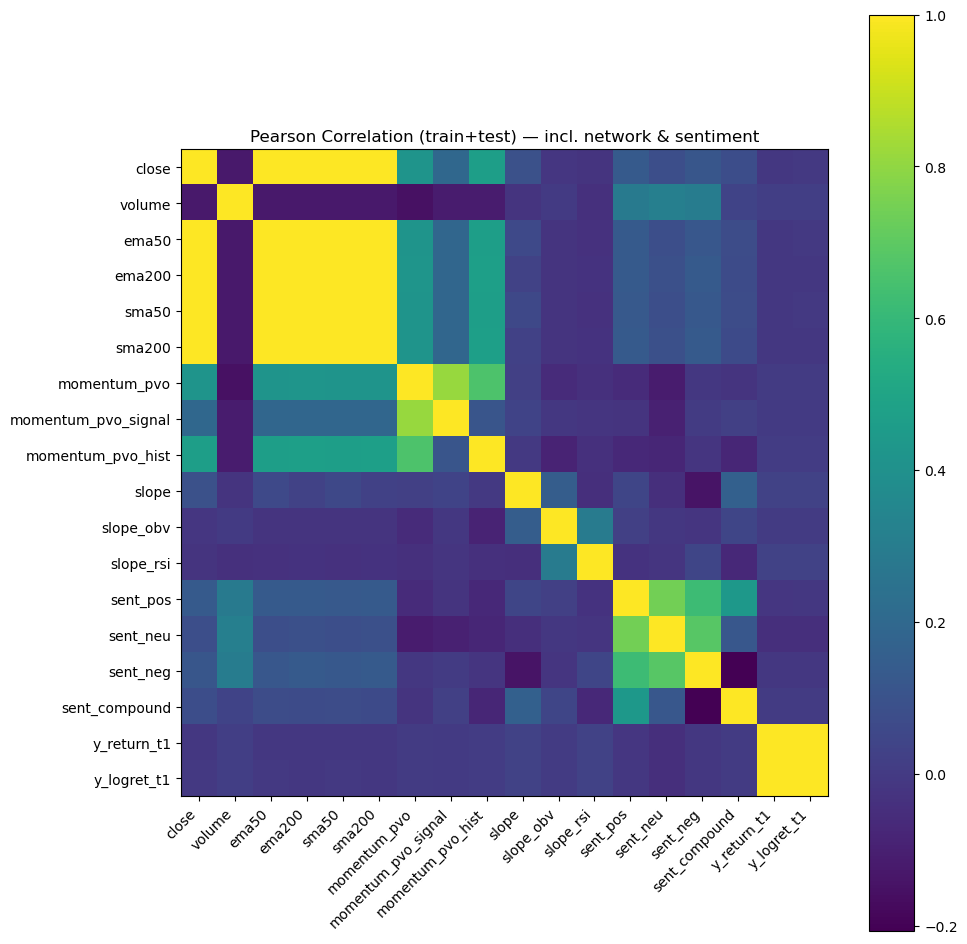

In [29]:
# ===== Correlation heatmap (includes network + sentiment; alias-aware; numeric-only) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Choose a dataframe (use your modeling matrix by default)
df_corr = dataset.copy()

# --- Candidate features (with aliases)
cands_pref = [
    # Core market
    "close","volume",
    # EMAs / SMAs
    "ema50","ema200","sma50","sma200",
    # RSI variants
    "RSI","rsi","rsi14",
    # Bollinger
    "Bollinger_Upper","Bollinger_Lower","bb_up","bb_lo",
    # Momentum / slopes (if present in your data)
    "MACD","macd","OBV","obv",
    "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
    "slope","slope_obv","slope_rsi",
    # NEW: network
    "hash_rate","mining_difficulty",
    # NEW: sentiment
    "sent_pos","sent_neu","sent_neg","sent_compound",
    # Target (optional)
    "y_return_t1","y_logret_t1"
]

# Alias groups → keep the first one that exists
alias_groups = [
    ["RSI","rsi","rsi14"],
    ["Bollinger_Upper","bb_up"],
    ["Bollinger_Lower","bb_lo"],
    ["MACD","macd"],
    ["OBV","obv"],
]

# Keep only present columns in preferred order
present = [c for c in cands_pref if c in df_corr.columns]

# De-dup aliases within same logical group
for grp in alias_groups:
    found = [c for c in grp if c in present]
    if len(found) > 1:
        # Keep only the first one in the group (based on cands_pref ordering)
        for c in found[1:]:
            present.remove(c)

# If nothing matched, fall back to any numeric columns
if not present:
    present = df_corr.select_dtypes(include=[np.number]).columns.tolist()

# Restrict to numeric and drop all-NaN columns
numeric = df_corr[present].select_dtypes(include=[np.number])
numeric = numeric.dropna(axis=1, how="all")

# If still too wide, pick top-k by variance (more informative)
top_k = 20
if numeric.shape[1] > top_k:
    variances = numeric.var().sort_values(ascending=False)
    keep_cols = variances.head(top_k).index.tolist()
    numeric = numeric[keep_cols]
else:
    keep_cols = numeric.columns.tolist()

# Compute Pearson correlation with pairwise complete observations
corr = numeric.corr(method="pearson")

plt.figure(figsize=(max(6, 0.45*len(keep_cols)+2), max(5, 0.45*len(keep_cols)+2)))
plt.imshow(corr.values, interpolation="nearest")
plt.xticks(range(len(keep_cols)), keep_cols, rotation=45, ha="right")
plt.yticks(range(len(keep_cols)), keep_cols)
plt.title("Pearson Correlation (train+test) — incl. network & sentiment")
plt.colorbar()
plt.tight_layout()
plt.show()


In [30]:
# ===== Prove inputs are shifted correctly =====
# Pick a feature to test — priority order: technical → network → sentiment → fallback
preferred_order = [
    "ema50","ema200","sma50","sma200",
    "hash_rate","mining_difficulty",
    "sent_compound","sent_pos","sent_neg","sent_neu"
]
feature = next((f for f in preferred_order if f in dataset.columns), dataset.columns[0])

# Ensure target exists
assert "y_return_t1" in dataset.columns or "y_close_t1" in dataset.columns, "Target not found."

target_col = "y_return_t1" if "y_return_t1" in dataset.columns else "y_close_t1"

# Slice down to feature + target, drop NaNs
ds = dataset[[feature, target_col]].dropna()

# Correlation between feature(t) and target(t+1)
corr_pair = ds[feature].corr(ds[target_col])
print(f"[SHIFT CHECK] Feature: {feature} | Target: {target_col}")
print(f"Correlation {feature}(t) vs {target_col}(t+1): {corr_pair:.4f}")

# Show sample rows to illustrate shift
print("\nFirst few rows showing alignment (feature at t vs target at t+1):")
print(ds.head(5))


[SHIFT CHECK] Feature: ema50 | Target: y_return_t1
Correlation ema50(t) vs y_return_t1(t+1): -0.0114

First few rows showing alignment (feature at t vs target at t+1):
                   ema50  y_return_t1
open_time                            
2018-02-26   9711.080761     0.023735
2018-02-27   9880.653287    -0.022924
2018-02-28  10319.186092     0.057447
2018-03-01  10472.402790     0.010897
2018-03-02  10630.940413     0.038543


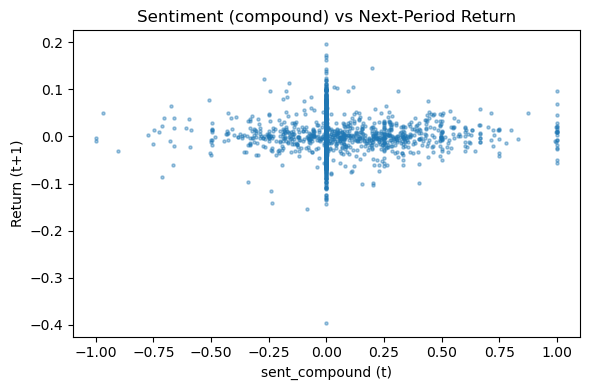

In [31]:
# ===== Scatter: Technical (RSI) / Network (hash_rate) / Sentiment (sent_compound) vs Next-Period Return =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

assert "dataset" in globals(), "Run the pipeline to create `dataset` first."
assert "y_return_t1" in dataset.columns, "`y_return_t1` missing."

# Choose RSI alias if present
rsi_col = next((c for c in ["rsi14","RSI","rsi"] if c in dataset.columns), None)

# Common helper to sample for lighter plotting
def _sample(df, n=5000, seed=42):
    if len(df) <= n:
        return df
    return df.sample(n, random_state=seed)

# 1) RSI vs next-period return
if rsi_col is not None:
    ds = dataset[[rsi_col, "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        plt.figure(figsize=(6,4))
        plt.scatter(sample[rsi_col].values, sample["y_return_t1"].values, s=5, alpha=0.4)
        freq_label = "Next-Day" if (dataset.index.to_series().diff().median() >= pd.Timedelta(hours=23)) else "Next-Hour"
        plt.title(f"{rsi_col.upper()} vs {freq_label} Return")
        plt.xlabel(f"{rsi_col} (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()

# 2) Hash rate vs next-period return (if available); use log scale on X if wide range
if "hash_rate" in dataset.columns:
    ds = dataset[["hash_rate", "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        x = sample["hash_rate"].astype(float).values
        # decide whether to log-scale
        do_log = (np.nanmax(x) / max(np.nanmin(x[x>0]) if np.any(x>0) else 1.0, 1.0)) > 100.0
        x_plot = np.log(x) if (do_log and np.all(x > 0)) else x
        plt.figure(figsize=(6,4))
        plt.scatter(x_plot, sample["y_return_t1"].values, s=5, alpha=0.4)
        plt.title("Hash Rate vs Next-Period Return")
        plt.xlabel("log(hash_rate) (t)" if (do_log and np.all(x > 0)) else "hash_rate (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()

# 3) Sentiment compound vs next-period return (if available)
if "sent_compound" in dataset.columns:
    ds = dataset[["sent_compound", "y_return_t1"]].dropna()
    if len(ds) >= 10:
        sample = _sample(ds, 5000)
        plt.figure(figsize=(6,4))
        plt.scatter(sample["sent_compound"].values, sample["y_return_t1"].values, s=5, alpha=0.4)
        plt.title("Sentiment (compound) vs Next-Period Return")
        plt.xlabel("sent_compound (t)")
        plt.ylabel("Return (t+1)")
        plt.tight_layout()
        plt.show()


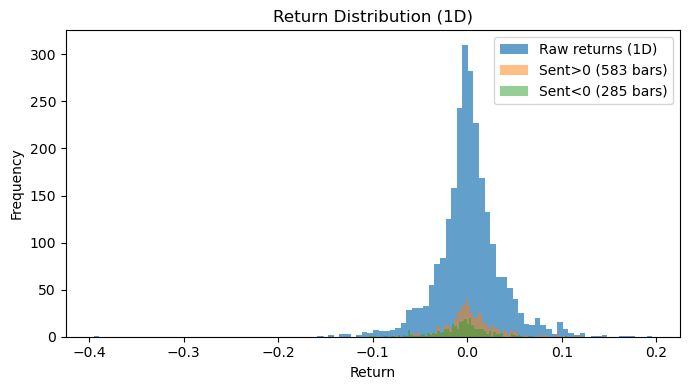

In [32]:
# ==== Return Distribution Plot (with new features awareness) ====
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

assert "dataset" in globals(), "Run the pipeline first."

# Determine cadence: hourly vs daily
median_diff = dataset.index.to_series().diff().median()
is_daily = median_diff >= pd.Timedelta(hours=23)
freq_label = "1D" if is_daily else "1H"

# Compute returns
ret = dataset["close"].pct_change().dropna()

plt.figure(figsize=(7,4))
plt.hist(ret.values, bins=100, alpha=0.7, label=f"Raw returns ({freq_label})")

# --- Optional overlays ---
# Sentiment overlay (if compound available): split distribution by pos vs neg
if "sent_compound" in dataset.columns:
    sent = dataset["sent_compound"].reindex(ret.index).fillna(0.0)
    mask_pos = sent > 0
    mask_neg = sent < 0
    if mask_pos.any():
        plt.hist(ret[mask_pos].values, bins=100, alpha=0.5, label=f"Sent>0 ({mask_pos.sum()} bars)")
    if mask_neg.any():
        plt.hist(ret[mask_neg].values, bins=100, alpha=0.5, label=f"Sent<0 ({mask_neg.sum()} bars)")

# Hash rate regime overlay (if available)
if "hash_rate" in dataset.columns:
    hr = dataset["hash_rate"].reindex(ret.index).dropna()
    if len(hr) > 20:
        median_hr = hr.median()
        mask_high = hr >= median_hr
        mask_low  = hr < median_hr
        plt.hist(ret[mask_high].values, bins=100, alpha=0.3, label="High hash_rate")
        plt.hist(ret[mask_low].values,  bins=100, alpha=0.3, label="Low hash_rate")

plt.title(f"Return Distribution ({freq_label})")
plt.xlabel("Return"); plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()


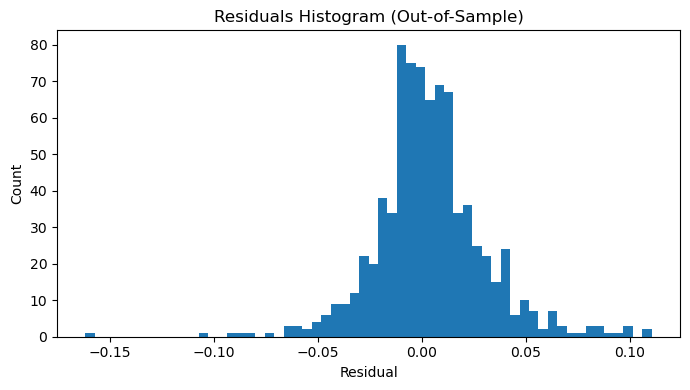

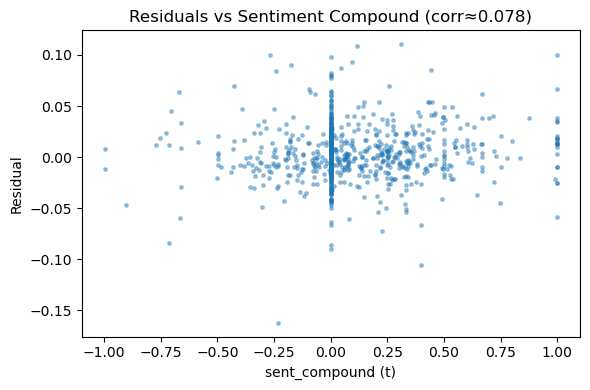

In [33]:
# ===== Residual diagnostics (incl. network + sentiment) =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Only run if reg_preds exists for a regression target (e.g., y_logret_t1 or y_close_t1)
if "reg_preds" in globals() and isinstance(reg_preds, pd.Series):
    # Infer a regression target present in dataset
    reg_target = None
    for cand in ["y_logret_t1", "y_return_t1", "y_close_t1"]:
        if cand in dataset.columns:
            reg_target = cand
            break

    if reg_target is not None:
        # Align indices safely
        common_idx = reg_preds.index.intersection(dataset.index)
        y_true = dataset.loc[common_idx, reg_target].astype(float)
        y_hat  = reg_preds.loc[common_idx].astype(float).reindex(common_idx)
        # Drop any NaNs from either side
        mask = y_true.notna() & y_hat.notna()
        y_true = y_true[mask]
        y_hat  = y_hat[mask]

        if len(y_true) < 10:
            raise RuntimeError("Not enough aligned predictions to plot residuals (<10).")

        resid = (y_true - y_hat).values

        # 1) Residuals histogram (main)
        plt.figure(figsize=(7,4))
        plt.hist(resid, bins=60)
        plt.title("Residuals Histogram (Out-of-Sample)")
        plt.xlabel("Residual"); plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        # 2) Residuals vs hash_rate (if available) — single scatter plot, log-aware x
        if "hash_rate" in dataset.columns:
            hr = dataset.loc[y_true.index, "hash_rate"].astype(float)
            hr_mask = hr.notna()
            if hr_mask.sum() >= 20:
                x = hr[hr_mask].values
                r = y_true[hr_mask].values - y_hat[hr_mask].values
                # Log scale if wide range and strictly positive
                use_log = (np.nanmax(x) > 0) and (np.nanmax(x) / max(np.nanmin(x[x>0]) if np.any(x>0) else 1.0, 1.0) > 100.0)
                x_plot = np.log(x) if (use_log and np.all(x > 0)) else x
                # Pearson corr (safe)
                try:
                    corr_val = np.corrcoef(x_plot, r)[0,1]
                except Exception:
                    corr_val = np.nan

                plt.figure(figsize=(6,4))
                plt.scatter(x_plot, r, s=6, alpha=0.4)
                xlabel = "log(hash_rate) (t)" if (use_log and np.all(x > 0)) else "hash_rate (t)"
                plt.title(f"Residuals vs Hash Rate (corr≈{corr_val:.3f})")
                plt.xlabel(xlabel); plt.ylabel("Residual")
                plt.tight_layout()
                plt.show()

        # 3) Residuals vs sentiment compound (if available) — single scatter plot
        if "sent_compound" in dataset.columns:
            sc = dataset.loc[y_true.index, "sent_compound"].astype(float)
            sc_mask = sc.notna()
            if sc_mask.sum() >= 20:
                x = sc[sc_mask].values
                r = (y_true - y_hat)[sc_mask].values
                # Pearson corr (safe)
                try:
                    corr_val = np.corrcoef(x, r)[0,1]
                except Exception:
                    corr_val = np.nan

                plt.figure(figsize=(6,4))
                plt.scatter(x, r, s=6, alpha=0.4)
                plt.title(f"Residuals vs Sentiment Compound (corr≈{corr_val:.3f})")
                plt.xlabel("sent_compound (t)"); plt.ylabel("Residual")
                plt.tight_layout()
                plt.show()
    else:
        print("No regression target column found (looked for y_logret_t1, y_return_t1, y_close_t1).")
else:
    print("reg_preds not available or not a pandas Series. Run your regression step first.")


In [34]:
# ===== Longest NaN streaks (cadence-aware; highlights network & sentiment) =====
import pandas as pd
import numpy as np

def longest_nan_streak(s: pd.Series) -> int:
    """Longest consecutive NaN run length."""
    m = s.isna().astype(int).values
    best = run = 0
    for v in m:
        run = run + 1 if v == 1 else 0
        if run > best:
            best = run
    return int(best)

# --- Pick a dataframe: prefer daily (cleaner), else modeling dataset, else raw df
if "df_daily" in globals():
    df_check = df_daily.copy()
elif "dataset" in globals():
    df_check = dataset.copy()
elif "df" in globals():
    df_check = df.copy()
else:
    raise RuntimeError("No dataframe found. Expected df_daily, dataset, or df.")

if not isinstance(df_check.index, pd.DatetimeIndex):
    raise TypeError("DataFrame index must be a DatetimeIndex.")

# --- Cadence detection (used only for labeling)
med_step = df_check.index.to_series().diff().median()
is_daily = (med_step is not pd.NaT) and (med_step >= pd.Timedelta(hours=23))
freq_label = "days" if is_daily else "bars"

# --- Numeric columns only
num_cols = df_check.select_dtypes(include=[np.number]).columns.tolist()
if not num_cols:
    raise RuntimeError("No numeric columns to analyze.")

# --- Compute longest streaks for all numeric columns
streaks = {c: longest_nan_streak(df_check[c]) for c in num_cols}
streaks = pd.Series(streaks).sort_values(ascending=False)

print(f"Top NaN streaks (units = consecutive {freq_label}):")
print(streaks.head(10))

# --- Highlight the NEW feature group explicitly
watch_cols = ["hash_rate", "mining_difficulty", "sent_pos", "sent_neu", "sent_neg", "sent_compound"]
present_watch = [c for c in watch_cols if c in df_check.columns]
if present_watch:
    print("\n[Network & Sentiment] Longest NaN streaks:")
    for c in present_watch:
        print(f"  {c:>16}: {longest_nan_streak(df_check[c])} {freq_label}")

# --- Optional: bucket summary (market / technical / network / sentiment)
feature_catalog = globals().get("feature_catalog", {
    "market": ["open","high","low","close","volume"],
    "technical": [
        "sma200","sma50","ema200","ema50","RSI","rsi","slope_rsi","MACD","macd",
        "OBV","obv","Bollinger_Upper","Bollinger_Lower",
        "momentum_pvo","momentum_pvo_signal","momentum_pvo_hist",
        "slope","slope_obv"
    ],
    "network": ["hash_rate","mining_difficulty"],
    "sentiment": ["sent_pos","sent_neu","sent_neg","sent_compound"],
})

# Map each present column to a bucket; others → 'other'
bucket_of = {}
for b, cols in feature_catalog.items():
    for c in cols:
        bucket_of[c] = b

streak_df = streaks.to_frame("longest_streak")
streak_df["bucket"] = [bucket_of.get(c, "other") for c in streak_df.index]

# Longest streak per bucket (max)
bucket_max = streak_df.groupby("bucket")["longest_streak"].max().sort_values(ascending=False)
print("\nMax NaN streak by bucket:")
print(bucket_max)

# (Optional) show worst offender per bucket
print("\nWorst column per bucket:")
worst_rows = []
for b in bucket_max.index:
    sub = streak_df[streak_df["bucket"] == b]
    if not sub.empty:
        worst = sub.sort_values("longest_streak", ascending=False).iloc[0]
        worst_rows.append((b, worst.name, int(worst["longest_streak"])))
for b, col, v in worst_rows:
    print(f"  {b:>10}: {col} → {v} {freq_label}")


Top NaN streaks (units = consecutive days):
hash_rate              2703
momentum_pvo_hist       192
momentum_pvo            192
momentum_pvo_signal     192
sma200                    8
trend_stc                 3
sma50                     2
trend_trix                1
trend_macd_diff           1
trend_macd                1
dtype: int64

[Network & Sentiment] Longest NaN streaks:
         hash_rate: 2703 days
          sent_pos: 0 days
          sent_neu: 0 days
          sent_neg: 0 days
     sent_compound: 0 days

Max NaN streak by bucket:
bucket
network      2703
technical     192
other           3
market          0
sentiment       0
Name: longest_streak, dtype: int64

Worst column per bucket:
     network: hash_rate → 2703 days
   technical: momentum_pvo_hist → 192 days
       other: trend_stc → 3 days
      market: open → 0 days
   sentiment: sent_neg → 0 days


[INFO] HMM not computed (install hmmlearn or more data needed): No module named 'hmmlearn'
Regime counts (MA):
regime_MA
Bull        1161
Bear         959
Sideways     583
Name: count, dtype: int64

Regime counts (RET):
regime_RET
Sideways    1114
Bull         965
Bear         624
Name: count, dtype: int64

Regime counts (RV):
regime_RV
Bull-Quiet       748
Bull-Volatile    725
Bear-Volatile    609
Bear-Quiet       591
Unknown           30
Name: count, dtype: int64

Regime counts (HMM):
regime_HMM
NaN    2703
Name: count, dtype: int64


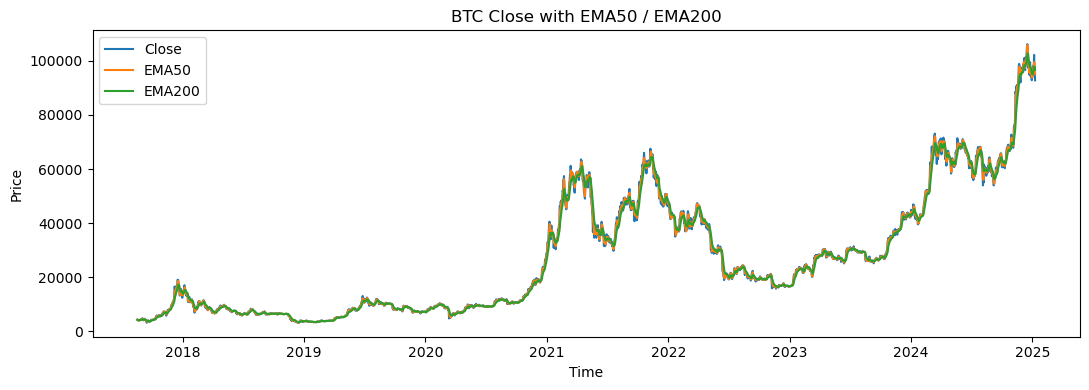

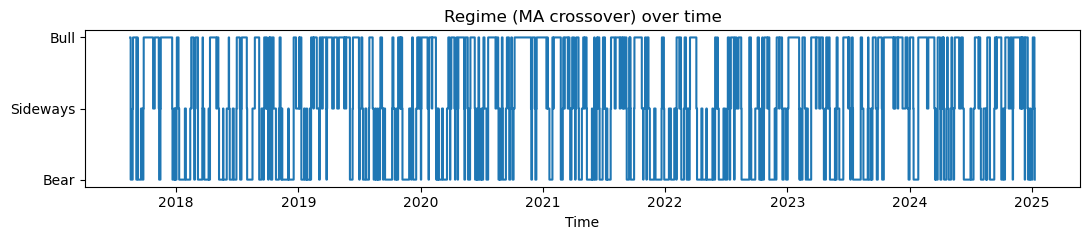

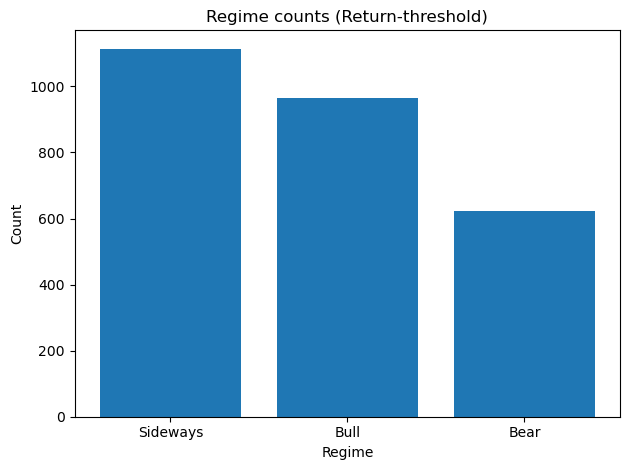

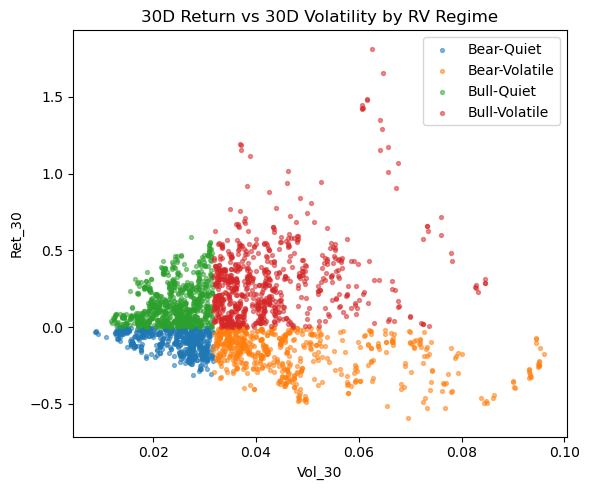

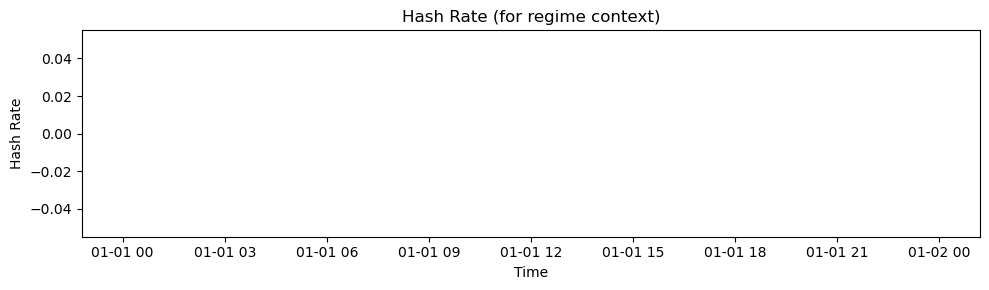

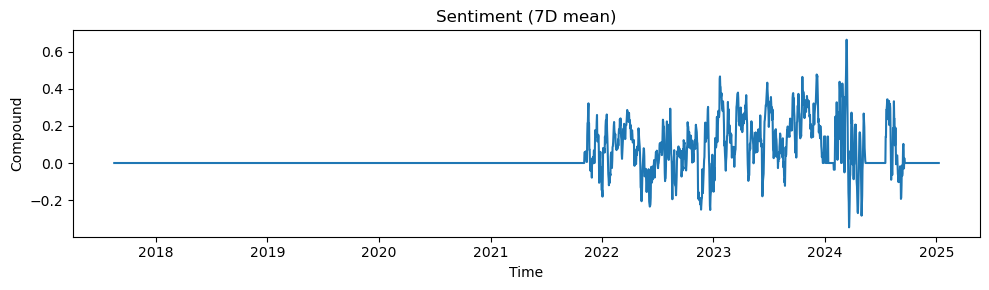

In [36]:
# ===== Market Regime Features + Simple Graphs =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- 0) Pick the working dataframe (daily preferred) ----------
if "df_daily" in globals():
    df_reg = df_daily.copy()
elif "dataset" in globals():
    df_reg = dataset.copy()
else:
    raise RuntimeError("No dataframe found. Expected `df_daily` or `dataset`.")

if not isinstance(df_reg.index, pd.DatetimeIndex):
    raise TypeError("Index must be a DatetimeIndex.")

# Ensure sorted
df_reg = df_reg.sort_index()

# ---------- 1) Prep: compute (or reuse) technical helpers ----------
# EMAs (if missing)
if "ema50" not in df_reg.columns:
    df_reg["ema50"] = df_reg["close"].ewm(span=50, adjust=False).mean()
if "ema200" not in df_reg.columns:
    df_reg["ema200"] = df_reg["close"].ewm(span=200, adjust=False).mean()

# Returns for thresholds / vol
df_reg["ret_1"]   = df_reg["close"].pct_change()
df_reg["ret_30"]  = df_reg["close"].pct_change(30)
df_reg["vol_30"]  = df_reg["ret_1"].rolling(30, min_periods=10).std()

# ---------- 2) Regime 1: Moving-average crossover (Bull/Bear/Sideways with buffer) ----------
# A small buffer on the EMA spread helps reduce whipsaws
spread = (df_reg["ema50"] - df_reg["ema200"]) / df_reg["ema200"]
buf = spread.rolling(10, min_periods=1).std().fillna(0) * 0.5  # adaptive buffer
cond_bull = spread >  buf
cond_bear = spread < -buf
df_reg["regime_MA"] = np.where(cond_bull, "Bull",
                        np.where(cond_bear, "Bear", "Sideways"))

# ---------- 3) Regime 2: Return-threshold (Bull/Bear/Sideways) ----------
# Tweak thresholds to taste
thr_up = 0.10   # +10% over 30D
thr_dn = -0.10  # -10% over 30D
df_reg["regime_RET"] = np.where(df_reg["ret_30"] > thr_up, "Bull",
                         np.where(df_reg["ret_30"] < thr_dn, "Bear", "Sideways"))

# ---------- 4) Regime 3: Return x Volatility (4 states) ----------
vol_med = df_reg["vol_30"].median()
df_reg["regime_RV"] = np.select(
    [
        (df_reg["ret_30"] > 0) & (df_reg["vol_30"] < vol_med),
        (df_reg["ret_30"] > 0) & (df_reg["vol_30"] >= vol_med),
        (df_reg["ret_30"] <= 0) & (df_reg["vol_30"] < vol_med),
        (df_reg["ret_30"] <= 0) & (df_reg["vol_30"] >= vol_med),
    ],
    ["Bull-Quiet", "Bull-Volatile", "Bear-Quiet", "Bear-Volatile"],
    default="Unknown"
)

# ---------- 5) (Optional) Regime 4: HMM on returns (if available) ----------
df_reg["regime_HMM"] = np.nan  # default
try:
    from hmmlearn.hmm import GaussianHMM
    rets = df_reg["ret_1"].dropna().values.reshape(-1, 1)
    if len(rets) > 500:
        hmm = GaussianHMM(n_components=3, covariance_type="full", random_state=42)
        hmm.fit(rets)
        states = pd.Series(hmm.predict(rets), index=df_reg["ret_1"].dropna().index, name="state")
        # Map states by mean/var ordering to named regimes
        state_stats = []
        for s in np.unique(states.values):
            s_vals = df_reg.loc[states.index[states.values==s], "ret_1"]
            state_stats.append((s, float(s_vals.mean()), float(s_vals.var())))
        # Sort by mean ascending: lowest mean -> Bear, mid -> Sideways, highest -> Bull
        order = [s for s, _, _ in sorted(state_stats, key=lambda x: x[1])]
        hmm_map = {order[0]: "Bear", order[1]: "Sideways", order[2]: "Bull"} if len(order)==3 else {order[0]:"Bear", order[-1]:"Bull"}
        df_reg.loc[states.index, "regime_HMM"] = states.map(hmm_map).values
except Exception as e:
    print("[INFO] HMM not computed (install hmmlearn or more data needed):", e)

# ---------- 6) One-hot encodings (useful for models) ----------
for col in ["regime_MA", "regime_RET", "regime_RV", "regime_HMM"]:
    if col in df_reg.columns:
        d = pd.get_dummies(df_reg[col], prefix=col, dummy_na=False)
        # Keep columns if at least some non-zero rows
        keep = [c for c in d.columns if d[c].sum() > 0]
        df_reg = df_reg.join(d[keep])

# ---------- 7) QUICK STATS ----------
print("Regime counts (MA):")
print(df_reg["regime_MA"].value_counts(dropna=False))
print("\nRegime counts (RET):")
print(df_reg["regime_RET"].value_counts(dropna=False))
print("\nRegime counts (RV):")
print(df_reg["regime_RV"].value_counts(dropna=False))
if "regime_HMM" in df_reg.columns:
    print("\nRegime counts (HMM):")
    print(df_reg["regime_HMM"].value_counts(dropna=False))

# ---------- 8) PLOTS (single-plot figures, matplotlib only) ----------

# 8.1 Price + EMAs (sanity)
plt.figure(figsize=(11,4))
plt.plot(df_reg.index, df_reg["close"], label="Close")
plt.plot(df_reg.index, df_reg["ema50"], label="EMA50")
plt.plot(df_reg.index, df_reg["ema200"], label="EMA200")
plt.title("BTC Close with EMA50 / EMA200")
plt.xlabel("Time"); plt.ylabel("Price"); plt.legend(); plt.tight_layout(); plt.show()

# 8.2 Regime timeline (MA) as integers (Bear=-1, Sideways=0, Bull=+1)
map_ma = {"Bear": -1, "Sideways": 0, "Bull": 1}
ma_series = df_reg["regime_MA"].map(map_ma)
plt.figure(figsize=(11,2.5))
plt.plot(ma_series.index, ma_series.values, drawstyle="steps-post")
plt.yticks(sorted(map_ma.values()), ["Bear","Sideways","Bull"])
plt.title("Regime (MA crossover) over time")
plt.xlabel("Time"); plt.tight_layout(); plt.show()

# 8.3 Regime distribution bars (RET)
ret_counts = df_reg["regime_RET"].value_counts()
plt.figure()
plt.bar(ret_counts.index.astype(str), ret_counts.values)
plt.title("Regime counts (Return-threshold)")
plt.xlabel("Regime"); plt.ylabel("Count"); plt.tight_layout(); plt.show()

# 8.4 Return vs Volatility scatter colored by RV labels (one plot; simple legend)
rv_sample = df_reg.dropna(subset=["ret_30","vol_30","regime_RV"])
if len(rv_sample) > 4000:
    rv_sample = rv_sample.sample(4000, random_state=42)
groups = rv_sample.groupby("regime_RV")
plt.figure(figsize=(6,5))
for name, g in groups:
    plt.scatter(g["vol_30"].values, g["ret_30"].values, s=8, alpha=0.5, label=name)
plt.title("30D Return vs 30D Volatility by RV Regime")
plt.xlabel("Vol_30"); plt.ylabel("Ret_30"); plt.legend(); plt.tight_layout(); plt.show()

# 8.5 (Optional) Overlay network/sentiment to see regime behavior
if "hash_rate" in df_reg.columns:
    plt.figure(figsize=(10,3))
    plt.plot(df_reg.index, df_reg["hash_rate"])
    plt.title("Hash Rate (for regime context)"); plt.xlabel("Time"); plt.ylabel("Hash Rate")
    plt.tight_layout(); plt.show()

if "sent_compound" in df_reg.columns:
    plt.figure(figsize=(10,3))
    plt.plot(df_reg.index, df_reg["sent_compound"].rolling(7, min_periods=1).mean())
    plt.title("Sentiment (7D mean)"); plt.xlabel("Time"); plt.ylabel("Compound")
    plt.tight_layout(); plt.show()

# ---------- 9) (Optional) hand back for downstream use ----------
#df_reg now contains regime columns and one-hots. You can merge back into df_daily/dataset if desired:
df_daily = df_reg  # if you want to persist in-session


[RF]  Test RMSE=0.027975 | MAE=0.020291 | R2=-0.1280
[XGB] Test RMSE=0.031149 | MAE=0.023068 | R2=-0.3984
[ENS] Test RMSE=0.029007 | MAE=0.021187

==== NEXT-STEP FORECAST ====
Last close (t):          96,957.14
RF predicted y_return_t1: -0.020197
XGB predicted y_return_t1: -0.022956
Ensemble y_return_t1:     -0.021576
RF next close (t+1):     94,998.95
Ensemble next close:      94,865.15
~95% PI for next close:  [89,581.41 , 100,148.90]


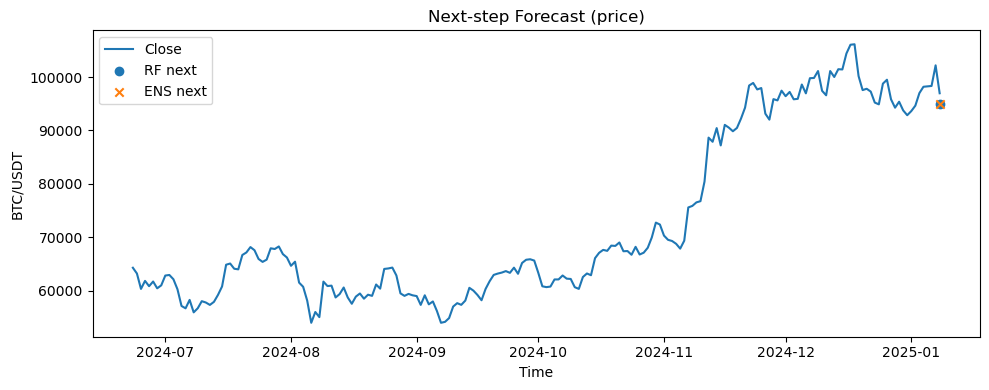

In [37]:
# ===== One-step-ahead FORECAST using all features (RF + XGB, ensemble) =====
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --------- Guards ---------
for v in ["dataset", "final_features"]:
    if v not in globals():
        raise RuntimeError(f"Missing `{v}`. Run your daily/hourly pipeline first.")

# Prefer these targets in order; will build one if needed
if "y_return_t1" in dataset.columns:
    target_reg = "y_return_t1"
elif "y_logret_t1" in dataset.columns:
    target_reg = "y_logret_t1"
else:
    # build simple next-step return on the fly (ok if you used daily pipeline with 'close' present)
    dataset["y_return_t1"] = (dataset["close"].shift(-1) / dataset["close"] - 1.0)
    dataset = dataset.dropna(subset=["y_return_t1"])
    target_reg = "y_return_t1"

# Final feature list present in the matrix
features = [f for f in final_features if f in dataset.columns]
if not features:
    raise RuntimeError("final_features are not present in `dataset` columns.")

# Train/test split for quick out-of-sample score (chronological 80/20)
N = len(dataset)
split_idx = max(1, min(int(N * 0.8), N - 1))
train = dataset.iloc[:split_idx].copy()
test  = dataset.iloc[split_idx:].copy()

X_tr, y_tr = train[features], train[target_reg]
X_te, y_te = test[features],  test[target_reg]

# Scale without leakage for evaluation
sc = StandardScaler().fit(X_tr)
X_trs = sc.transform(X_tr)
X_tes = sc.transform(X_te)

# ---- Model A: Random Forest
rf = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    random_state=42, n_jobs=-1
)
rf.fit(X_trs, y_tr)
rf_pred_te = rf.predict(X_tes)

# ---- Model B: XGBoost (optional, auto-skip if not available)
xgb_pred_te = None
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=600, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        tree_method="hist", random_state=42, n_jobs=-1
    )
    xgb.fit(X_trs, y_tr)
    xgb_pred_te = xgb.predict(X_tes)
except Exception as e:
    print("[INFO] XGBoost unavailable/failed, continuing with RF only:", e)

# ---- Quick OOS metrics (test split)
def _rmse(a,b): return float(np.sqrt(np.mean((np.asarray(a)-np.asarray(b))**2)))
def _mae(a,b):  return float(np.mean(np.abs(np.asarray(a)-np.asarray(b))))

rf_rmse = _rmse(y_te, rf_pred_te)
rf_mae  = _mae(y_te, rf_pred_te)
print(f"[RF]  Test RMSE={rf_rmse:.6f} | MAE={rf_mae:.6f} | R2={r2_score(y_te, rf_pred_te):.4f}")

if xgb_pred_te is not None:
    xgb_rmse = _rmse(y_te, xgb_pred_te)
    xgb_mae  = _mae(y_te, xgb_pred_te)
    print(f"[XGB] Test RMSE={xgb_rmse:.6f} | MAE={xgb_mae:.6f} | R2={r2_score(y_te, xgb_pred_te):.4f}")

# ---- Ensemble on test (avg) for reference
if xgb_pred_te is not None:
    ens_pred_te = 0.5*rf_pred_te + 0.5*xgb_pred_te
    print(f"[ENS] Test RMSE={_rmse(y_te, ens_pred_te):.6f} | MAE={_mae(y_te, ens_pred_te):.6f}")
else:
    ens_pred_te = rf_pred_te

# ======================================================================
# LIVE FORECAST (next period): refit on ALL data, predict next-step target
# ======================================================================
X_all, y_all = dataset[features], dataset[target_reg]
sc_all = StandardScaler().fit(X_all.values)
X_all_s = sc_all.transform(X_all.values)

rf_all = RandomForestRegressor(
    n_estimators=500, max_depth=None, min_samples_leaf=2,
    random_state=42, n_jobs=-1
).fit(X_all_s, y_all.values)

xgb_all = None
if 'XGBRegressor' in globals():
    try:
        xgb_all = XGBRegressor(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            tree_method="hist", random_state=42, n_jobs=-1
        ).fit(X_all_s, y_all.values)
    except Exception as e:
        print("[INFO] XGB live refit failed, using RF only:", e)

# latest feature vector (t) to predict target at (t+1)
x_last_raw = X_all.iloc[-1].values.reshape(1, -1)
x_last_s   = sc_all.transform(x_last_raw)

rf_next  = float(rf_all.predict(x_last_s)[0])
if xgb_all is not None:
    xgb_next = float(xgb_all.predict(x_last_s)[0])
    ens_next = 0.5*rf_next + 0.5*xgb_next
else:
    xgb_next = None
    ens_next = rf_next

# Convert target -> next close price
close_t = float(dataset["close"].iloc[-1])
if target_reg == "y_logret_t1":
    # log-return
    price_rf  = close_t * np.exp(rf_next)
    price_ens = close_t * np.exp(ens_next)
else:
    # simple return
    price_rf  = close_t * (1.0 + rf_next)
    price_ens = close_t * (1.0 + ens_next)

print("\n==== NEXT-STEP FORECAST ====")
print(f"Last close (t):          {close_t:,.2f}")
print(f"RF predicted {target_reg}: {rf_next:+.6f}")
if xgb_next is not None:
    print(f"XGB predicted {target_reg}: {xgb_next:+.6f}")
print(f"Ensemble {target_reg}:     {ens_next:+.6f}")
print(f"RF next close (t+1):     {price_rf:,.2f}")
print(f"Ensemble next close:      {price_ens:,.2f}")

# ---- Simple prediction interval via residuals on test (normal approx)
resids = y_te.values - ens_pred_te  # ensemble residuals on test (or RF if no XGB)
sigma  = float(np.std(resids)) if len(resids) > 5 else float(np.std(y_te.values - rf_pred_te))
z95    = 1.96

if target_reg == "y_logret_t1":
    lo = close_t * np.exp(ens_next - z95*sigma)
    hi = close_t * np.exp(ens_next + z95*sigma)
else:
    lo = close_t * (1.0 + ens_next - z95*sigma)
    hi = close_t * (1.0 + ens_next + z95*sigma)

print(f"~95% PI for next close:  [{lo:,.2f} , {hi:,.2f}]")

# (Optional) quick plot of last 200 points + next-step forecasts
import matplotlib.pyplot as plt
tail_n = 200 if len(dataset) > 220 else max(50, int(len(dataset)*0.8))
idx_tail = dataset.index[-tail_n:]
plt.figure(figsize=(10,4))
plt.plot(idx_tail, dataset["close"].iloc[-tail_n:], label="Close")
plt.scatter([dataset.index[-1]], [price_rf],  label="RF next",  marker="o")
plt.scatter([dataset.index[-1]], [price_ens], label="ENS next", marker="x")
plt.title("Next-step Forecast (price)")
plt.xlabel("Time"); plt.ylabel("BTC/USDT"); plt.legend(); plt.tight_layout(); plt.show()
